In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
import networkx as nx


plt.rc('font',family='Times New Roman')

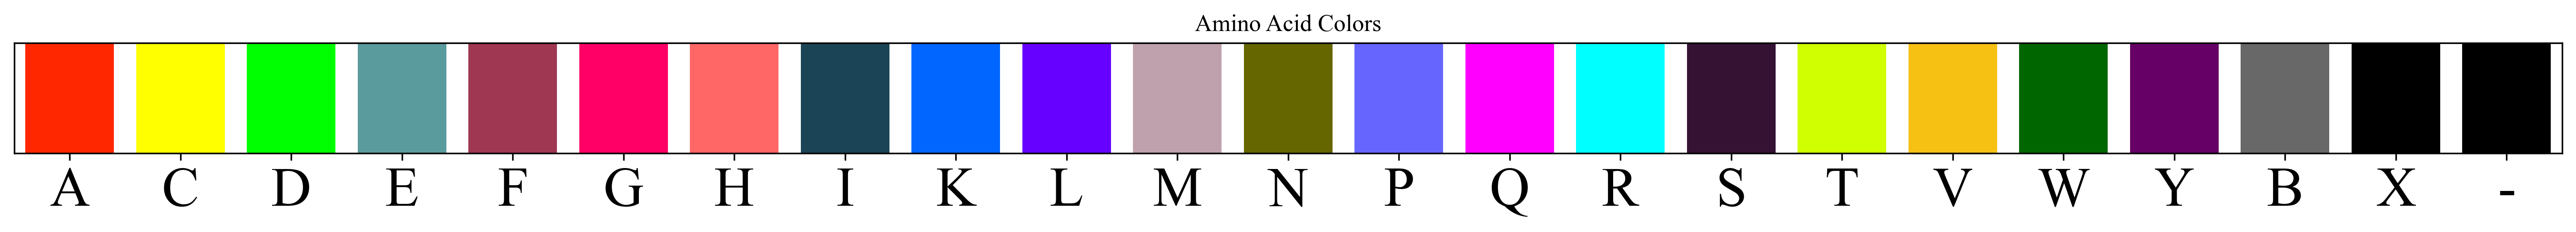

In [2]:
def plot_amino_acid_colors(amino_acid_colors):
    fig = plt.figure(figsize=(len(amino_acid_colors), 1), dpi=300)
    ax = fig.add_subplot(111)
    ax.set_title("Amino Acid Colors")
    ax.set_xticks(range(len(amino_acid_colors)))
    ax.set_xticklabels(amino_acid_colors.keys(), fontsize=28)
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.set_xlim(-0.5, len(amino_acid_colors)-0.5)
    ax.set_ylim(0, 1)
    ax.bar(range(len(amino_acid_colors)), [1] * len(amino_acid_colors), color=amino_acid_colors.values())
    plt.show()


strain_colors = {
 'HY': '#2BA02B',
 'ΔL234': '#FF64C9',
 'N298D': '#8C564C',
 'K421R': '#D62727',
 'T489A': '#00C5D5',
 'G472E': '#a1ff3d',
 'E448K': '#2B55AD',
 'K421R/T489A': '#FF7F0F',
 'ΔL234/R237I': '#1F77B4',
 'L234M/M235V': '#9467BD',
 'L234M/R237I': '#5DF9FB',
 'S211N/L234M/M235V': '#c0a98e',
 'L234M/M235V/T300A': '#ffd400'
 }


color_dict = {
    'mut': '#1F77B4',
    'ms_mut': '#e86800',
    'ss_mut': '#4da409',
    'ns_mut': '#000000',
    'delete': '#686868',
    'insert': '#b00149',}


amino_acid_colors = {'A': '#ff2700',
                     'C': '#FFFF00',
                     'D': '#00FF00',
                     'E': '#5a9b9d',
                     'F': '#9f3753',
                     'G': '#FF0066',
                     'H': '#FF6666',
                     'I': '#1b4556',
                     'K': '#0066FF',
                     'L': '#6600FF',
                     'M': '#bfa1ad',
                     'N': '#666600',
                     'P': '#6666FF',
                     'Q': '#FF00FF',
                     'R': '#00FFFF',
                     'S': '#351234',
                     'T': '#cfff00',
                     'V': '#f7c114',
                     'W': '#006600',
                     'Y': '#660066',
                     'B': '#686868',
                     'X': '#000000',
                     '-': '#000000',}
plot_amino_acid_colors(amino_acid_colors)

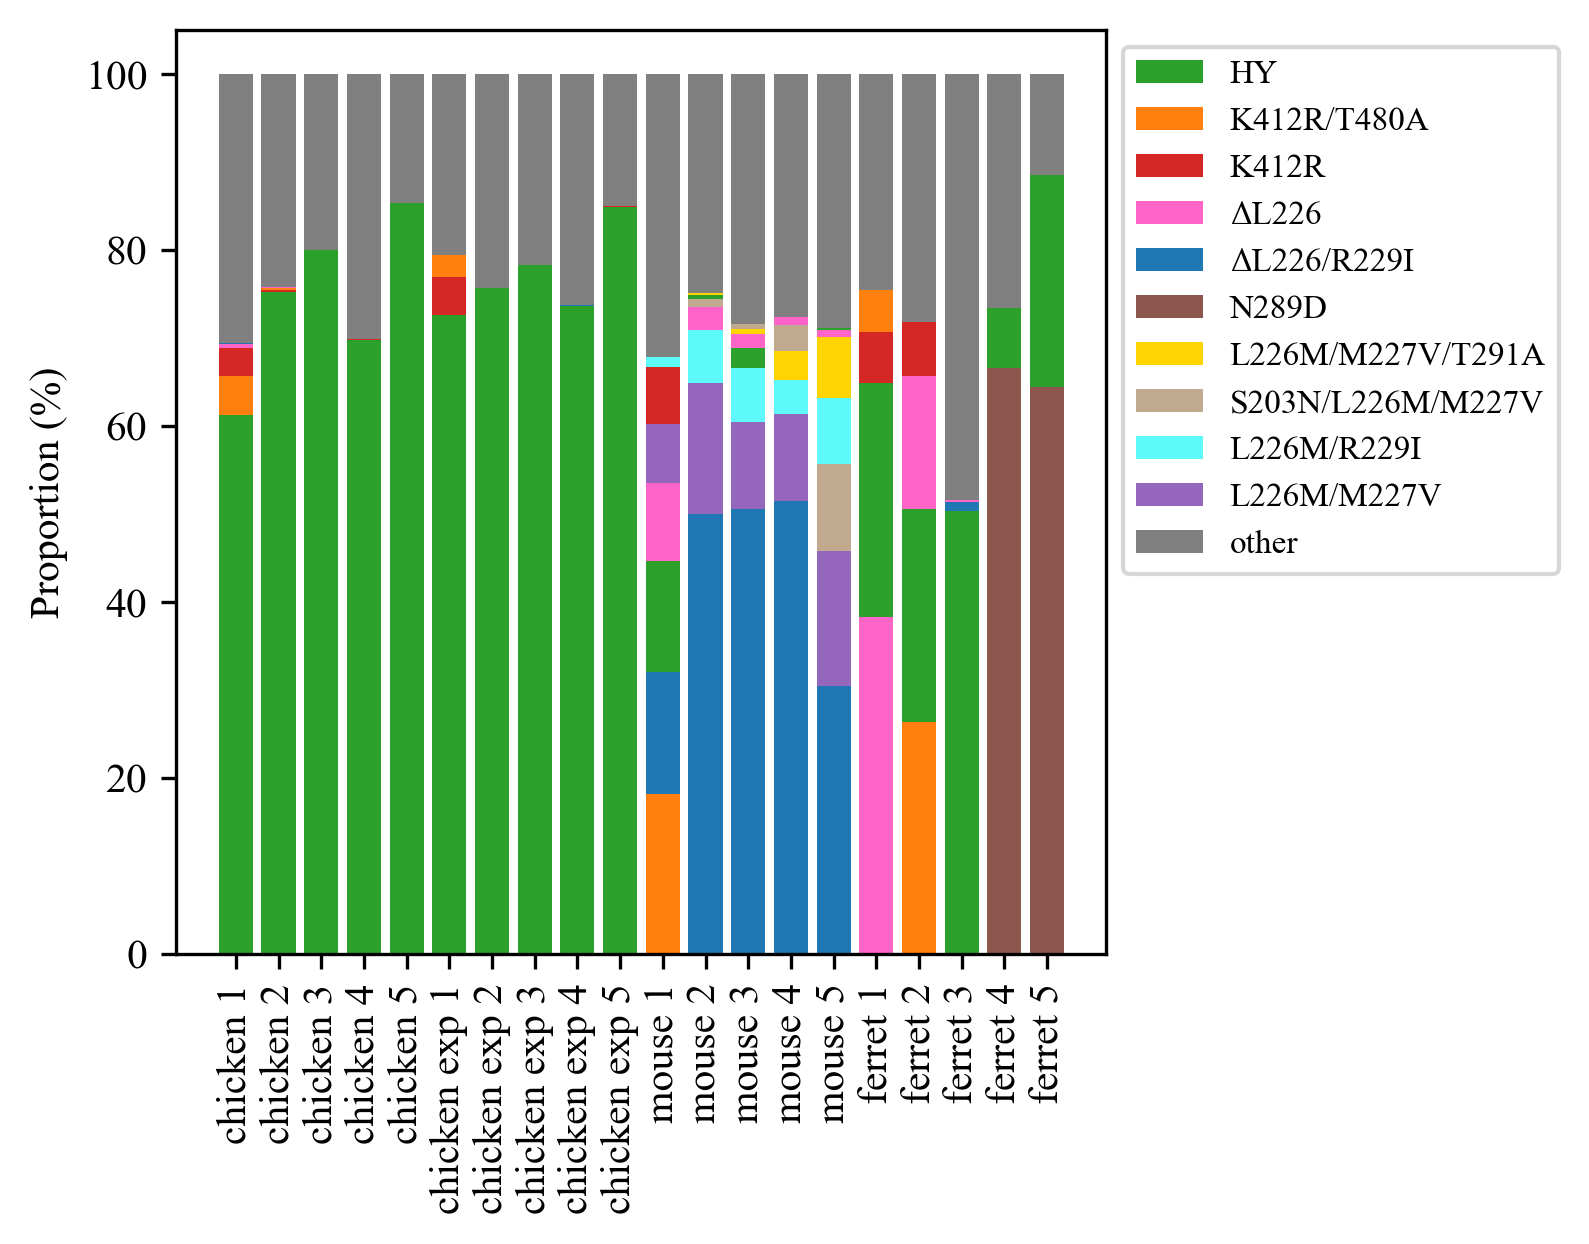

In [3]:
def plot_bar(animal_varients_df, title, figsize=(4,4), rotation=90, skip_threshold=0, xlabel=None):
    plt.figure(figsize=figsize, dpi=300)
    x = 0
    for sample in animal_varients_df.index:
        
        sample_df = animal_varients_df.loc[sample].sort_values(ascending=False)
        
        keys = sample_df.keys()
        values = sample_df.values
        
        bottom = 0
        for i in range(len(keys)):
            if values[i]/100 < skip_threshold:
                continue
                
            label = keys[i].replace('117', '106').replace('211', '203').replace('234', '226')
            label = label.replace('235', '227').replace('237', '229').replace('298', '289')
            label = label.replace('300', '291').replace('421', '412').replace('489', '480')
                
            plt.bar(x=x, height=values[i], bottom=bottom, label=label, color=strain_colors[keys[i]])
            bottom += values[i]
            
        plt.bar(x, 100-bottom, bottom=bottom, color='gray', label='other')
        
        x += 1

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1, 1), fontsize=8)
    plt.xticks(range(len(animal_varients_df.index)), animal_varients_df.index, rotation=rotation)
    plt.ylabel('Proportion (%)')
    if xlabel != None:
        plt.xlabel(xlabel)
    plt.savefig(f'{title}.pdf', bbox_inches='tight')
    plt.show()

animal_varients_df = pd.read_csv('animal_varients_df.csv', index_col=0)
plot_bar(animal_varients_df, title='animal_varients', skip_threshold=0.0, figsize=(4,4), rotation=90)

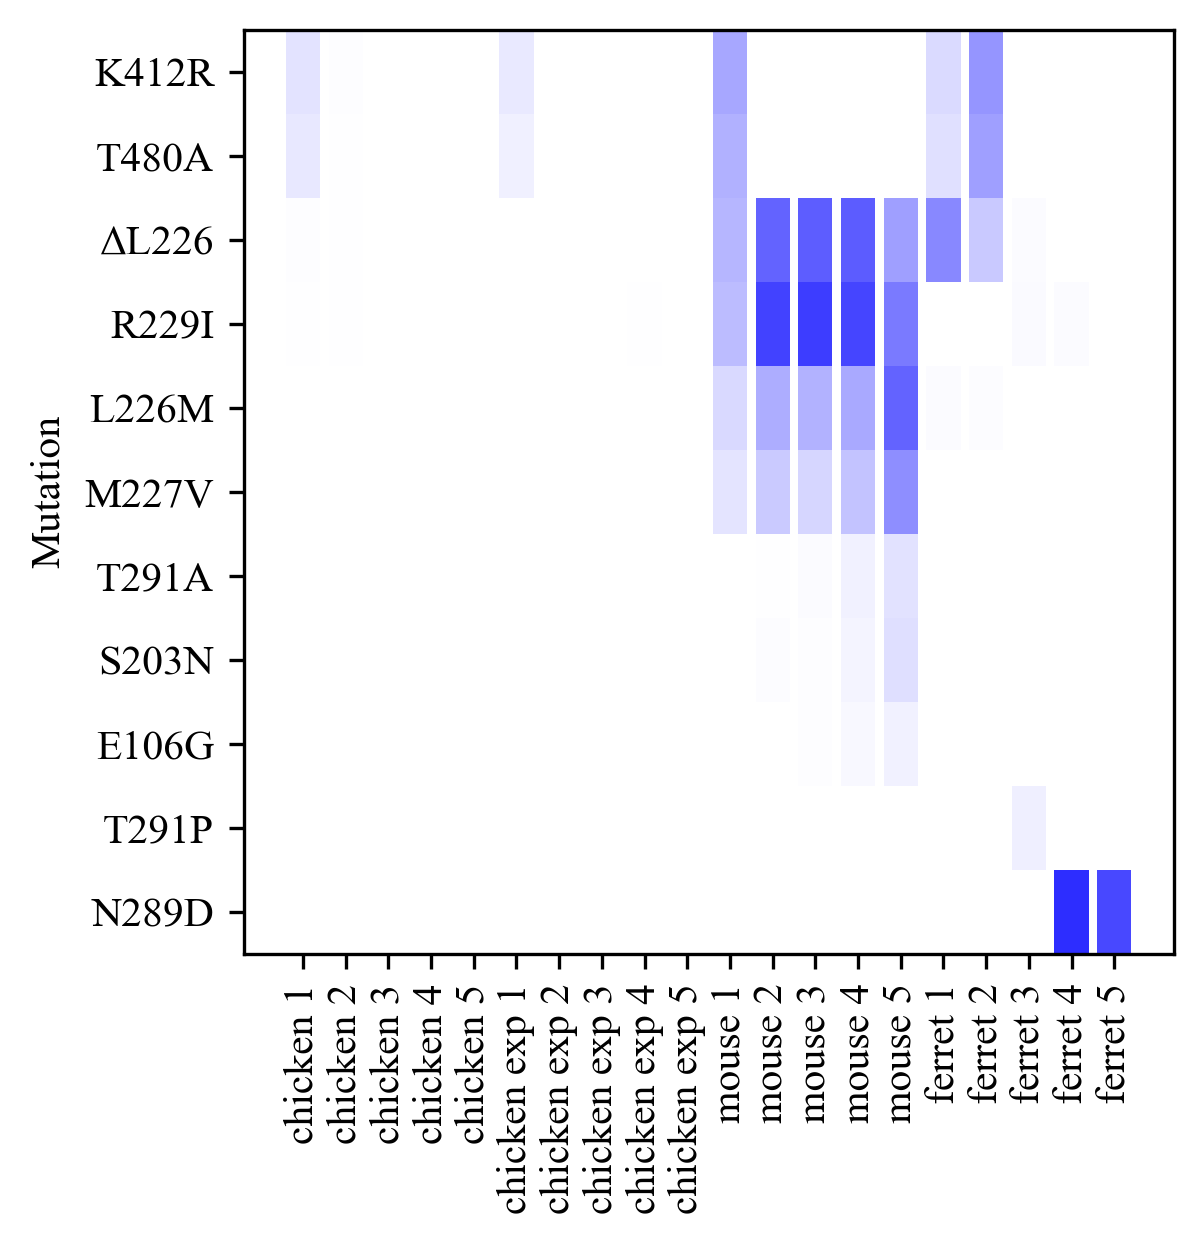

In [190]:
def plot_heatmap(animal_varients_df, figsize=(7,3), rotation=90, skip_threshold=0):
        
    plt.figure(figsize=figsize, dpi=300)
    x = 0    
    for sample in animal_varients_df.index:
        
        sample_df = animal_varients_df.loc[sample]#.sort_values(ascending=False)
        
        keys = sample_df.keys()
        values = sample_df.values
        
        bottom = -1.5
        for i in range(len(keys)):
            height = 1
            bottom += height
            if values[i]/100 < skip_threshold:
                continue
                
            plt.bar(x=x, height=1, bottom=bottom, color='blue', alpha=values[i]/100)
        
        x += 1

    plt.ylim(-0.5, len(animal_varients_df.keys())-0.5)
    
    new_y_ticks = []
    for y_ticks in animal_varients_df.keys():
        y_ticks = y_ticks.replace('117', '106').replace('211', '203').replace('234', '226')
        y_ticks = y_ticks.replace('235', '227').replace('237', '229').replace('298', '289')
        y_ticks = y_ticks.replace('300', '291').replace('421', '412').replace('489', '480')
        new_y_ticks.append(y_ticks)
    
    plt.yticks(range(len(animal_varients_df.keys())), new_y_ticks)
    plt.xticks(range(len(animal_varients_df.index)), animal_varients_df.index, rotation=rotation)
    plt.ylabel('Mutation')
    plt.savefig('animal_mutations_heatmap.pdf', bbox_inches='tight')
    plt.show()

animal_mutations_df = pd.read_csv('animal_mutations_df.csv', index_col=0)
plot_heatmap(animal_mutations_df, figsize=(4,4), rotation=90, skip_threshold=0)

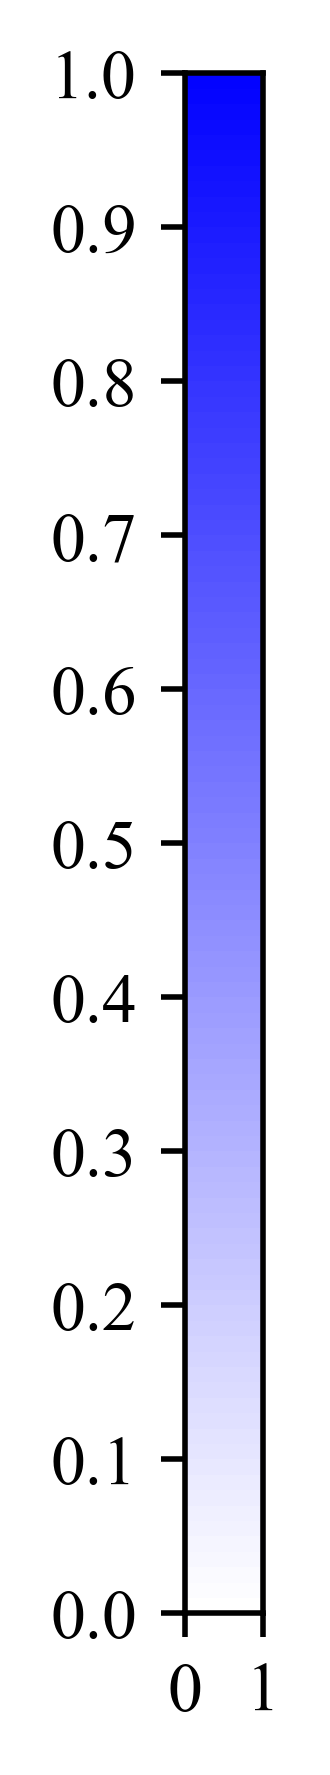

In [191]:
def plot_heatmap(animal_varients_df, figsize=(7,3), rotation=90, skip_threshold=0):
        
    plt.figure(figsize=figsize, dpi=500)
    for x in range(1,101):

        plt.bar(x=0.5, height=1, bottom=x, width=1, color='blue', alpha=x/100)

    plt.ylim(0,100)
    plt.xlim(0,1)
    plt.yticks(np.arange(0,101,10), [y/100 for y in range(0,101,10)])
    plt.savefig('heatmap_legend.pdf')
    plt.show()

animal_mutations_df = pd.read_csv('animal_mutations_df.csv', index_col=0)
plot_heatmap(animal_mutations_df, figsize=(0.2,4), rotation=90, skip_threshold=0)

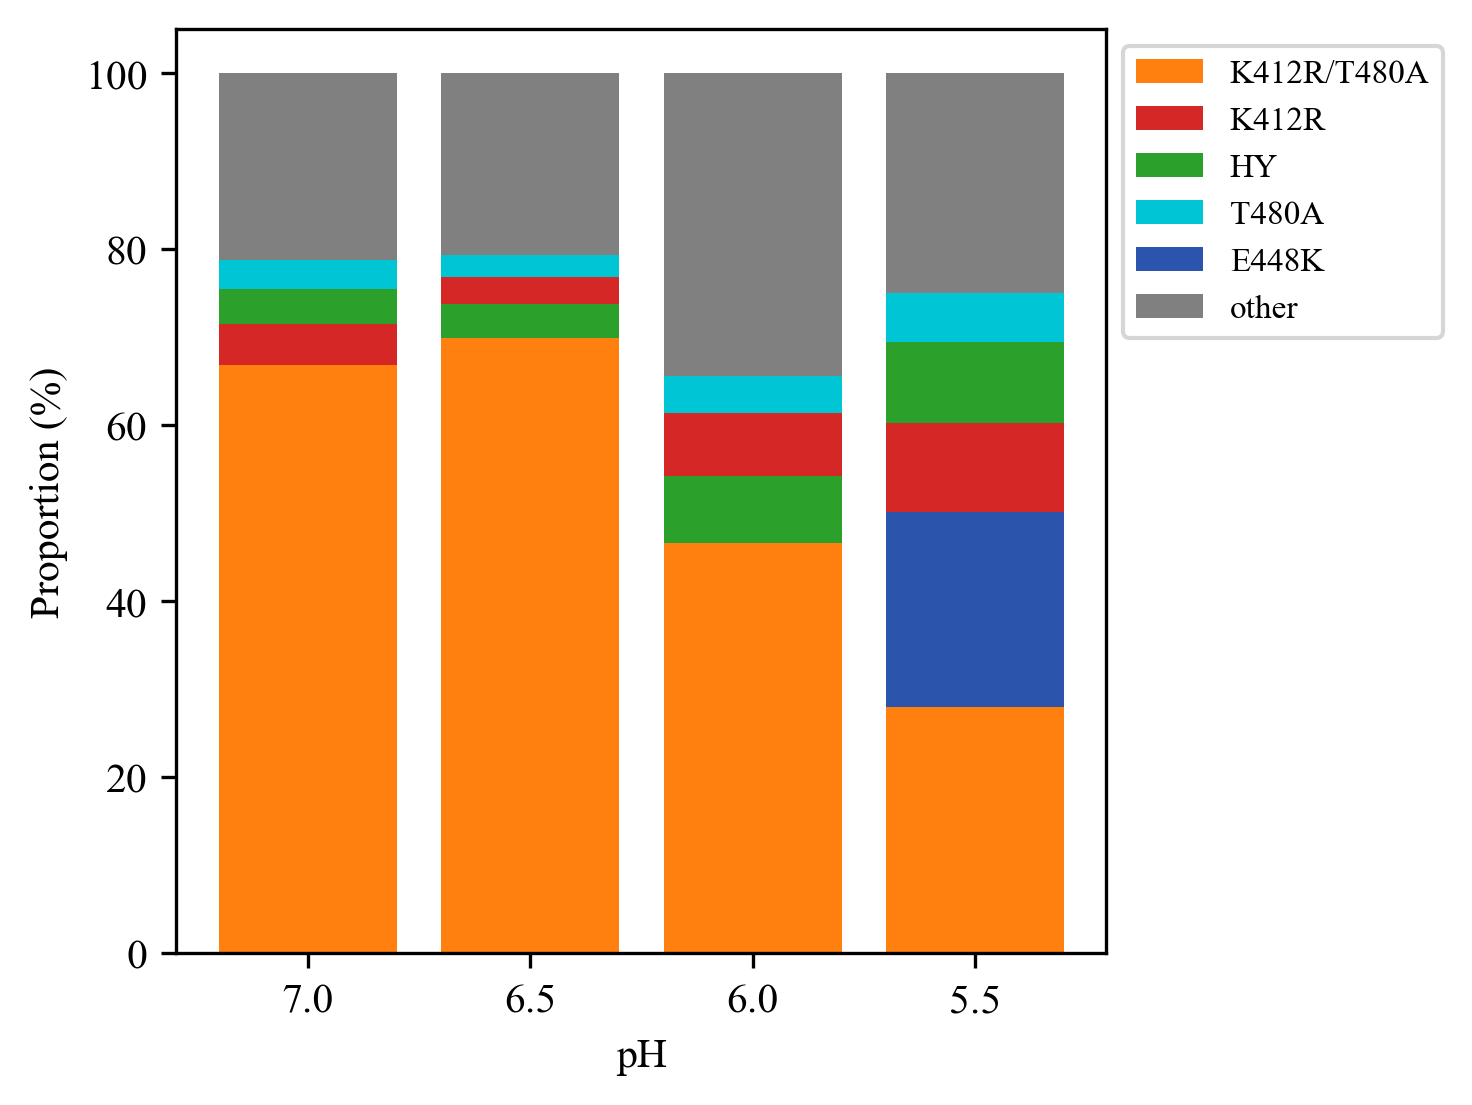

In [192]:
acid_varient = pd.read_csv('acid_varient.csv', index_col=0)
plot_bar(acid_varient,title='acid_varient', skip_threshold=0.0, figsize=(4,4), rotation=0, xlabel='pH')

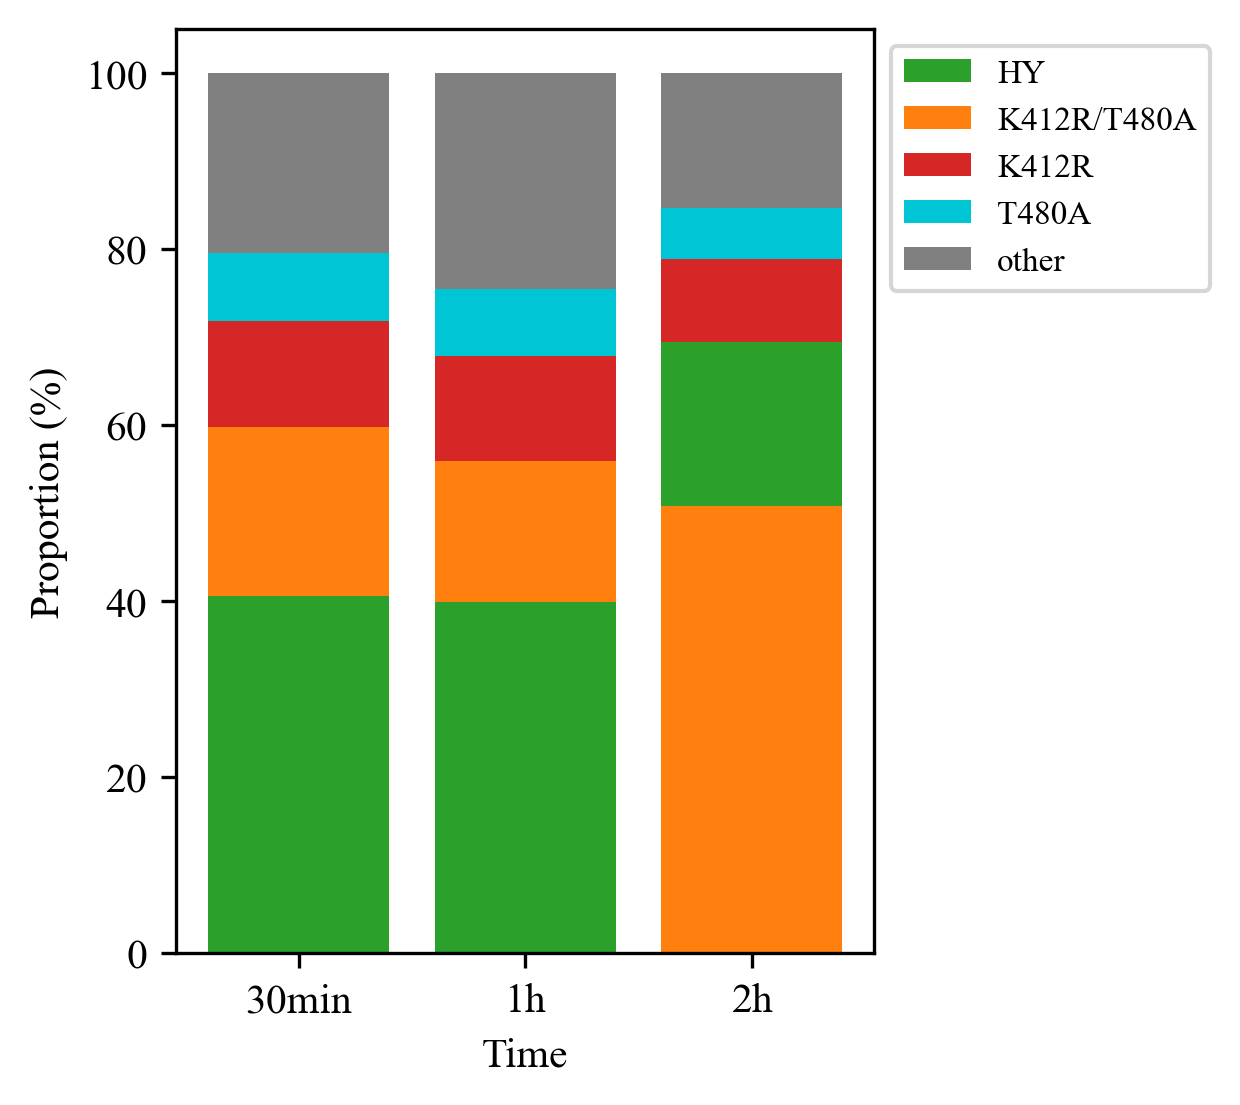

In [193]:
thermal_varient = pd.read_csv('thermal_varient.csv', index_col=0)
plot_bar(thermal_varient, title='thermal_varient', skip_threshold=0.0, figsize=(3,4), rotation=0, xlabel='Time')

In [4]:
import seaborn as sns
import scipy.cluster.hierarchy as sch
from matplotlib.colors import Normalize

def plot_clustermap(gene_df, sample_list, save_path, cmap='RdBu_r', cluster_num=10, method='single', ylabel=0, figsize=(10, 10)):
    # clustermap
    cluster_result = sns.clustermap(data=gene_df[sample_list], 
                                    cmap='RdBu_r',
                                    col_cluster=0,
                                    row_cluster=1, 
                                    xticklabels=sample_list,#[i.split('_')[1] for i in sample_list],
                                    yticklabels=0,
                                    method = method, 
                                    figsize=(1,1),)

    linkage_matrix = cluster_result.dendrogram_row.linkage

    num_clusters = cluster_num
    row_clusters = sch.fcluster(linkage_matrix, num_clusters, criterion='maxclust')

    cluster_colors = {0: 'red', 1: 'green', 2: 'blue', 3: 'orange', 4: 'purple', 5: 'pink', 6: 'brown', 7: 'gray', 8: 'yellow', 9: 'cyan'}
    
    row_colors = [cluster_colors[c-1] for c in row_clusters]

    max_value = max([abs(gene_df[sample_list].min().min()), abs(gene_df[sample_list].max().max())])
    
    norm = Normalize(vmin=-max_value, vmax=max_value)
    
    cluster_result = sns.clustermap(data=gene_df[sample_list],
                                    cmap=cmap,
                                    norm = norm,
                                    col_cluster=0,
                                    row_cluster=1,
                                    xticklabels=sample_list,#[i.split('_')[1] for i in sample_list],
                                    yticklabels=gene_df.index.tolist() if ylabel == 1 else 0,
                                    row_colors=row_colors,
                                    method = method, 
                                    figsize=figsize)
    plt.savefig(f'{save_path}_clustermap.pdf', bbox_inches='tight')
    plt.savefig(f'{save_path}_clustermap.png', bbox_inches='tight')

    for row_cluster, symbol in zip(row_clusters, gene_df.index.tolist()):
        color = cluster_colors[row_cluster-1]
        gene_df.loc[symbol, 'cluster'] = row_cluster
        gene_df.loc[symbol, 'color'] = color

    gene_df.to_csv(f'{save_path}_clustermap.csv')
        
    return gene_df

In [2]:
id2genename = {}
gene_info_df = pd.read_csv('id2genename.txt', sep = '\t')
gene_info_df['symbol'] = ''
for i in gene_info_df.index:
    gene_name = gene_info_df.loc[i, 'Gene Name']
    symbol = re.findall(r'\((.*?)\)', gene_info_df.loc[i, 'Gene Name'])[-1]
    gene_info_df.loc[i, 'symbol'] = symbol
    id2genename[gene_info_df.loc[i, 'From']] = symbol
gene_info_df

,From,To,Species,Gene Name,symbol
0,ENSMUSG00000042808,14776,Mus musculus,glutathione peroxidase 2(Gpx2),Gpx2
1,ENSMUSG00000042804,100129,Mus musculus,G protein-coupled receptor 153(Gpr153),Gpr153
2,ENSMUSG00000042807,329152,Mus musculus,"HECT, C2 and WW domain containing E3 ubiquitin...",Hecw2
3,ENSMUSG00000042801,257667,Mus musculus,olfactory receptor family 6 subfamily C member...,Or6c2b
4,ENSMUSG00000042800,76925,Mus musculus,spermatogenesis associated 46(Spata46),Spata46
...,...,...,...,...,...
30157,ENSMUSG00000086552,320453,Mus musculus,"distal-less homeobox 4, opposite strand(Dlx4os)",Dlx4os
30158,ENSMUSG00000074577,69553,Mus musculus,RIPOR family member 3(Ripor3),Ripor3
30159,ENSMUSG00000074578,68949,Mus musculus,"zinc finger, NFX1-type containing 1, antisense...",Zfas1
30160,ENSMUSG00000086550,76684,Mus musculus,"phospholipase A2, group X, opposite strand(Pla...",Pla2g10os


In [9]:
df = pd.DataFrame(columns=['compare_with', 'dpi', 'varient', 'upregulation', 'downregulation'])
top_degs_list = []

for vs in ['0', 'HY']:
    for day_post_infection in [5, 3]:
        if vs == 'HY':
            sample_list = ['KT', 'N289D', 'T7', ]
        elif str(vs) == '0':
            sample_list = ['KT', 'N289D', 'T7', 'HY', ]
        for sample in sample_list:
            degs_result_path = f'vs{vs}/{day_post_infection}dpi_{sample}_vs_{day_post_infection}dpi_{vs}.DE_result'
            degs_result = pd.read_csv(degs_result_path, index_col=0)
            degs_result = degs_result.sort_values('logFC', ascending=False)
            sample_name = f'{day_post_infection}dpi_{sample}'
            for name_0, name_1 in {'KT': 'K412R/T480A', 'T7': 'ΔL226/R229I',}.items():
                sample_name = sample_name.replace(name_0, name_1)
            n = 5
            degs_result['top'] = 0
            for i in degs_result[-n:].index:
                degs_result.loc[i, 'top'] = 1
            for i in degs_result[:n].index:
                degs_result.loc[i, 'top'] = 1

            up_symbol_list = []
            for i in degs_result[:n].index:
                symbol = degs_result.loc[i, 'symbol']
                up_symbol_list.append(symbol)
                if symbol not in top_degs_list:
                    top_degs_list.append(symbol)
            down_symbol_list = []
            for i in degs_result[-n:].index:
                symbol = degs_result.loc[i, 'symbol']
                down_symbol_list.append(symbol)
                if symbol not in top_degs_list:
                    top_degs_list.append(symbol)

            df = pd.concat([df, pd.DataFrame({'compare_with':[vs.replace('0', 'control').replace('HY', 'wild type HY')], 
                                            'dpi':[day_post_infection], 
                                            'varient':[sample], 
                                            'upregulation':[', '.join(up_symbol_list)], 
                                            'downregulation':[', '.join(down_symbol_list)], 
                                            })], ignore_index=1)

df.to_csv('up_down_gene.csv', index=False)
df

,compare_with,dpi,varient,upregulation,downregulation
0,control,5,KT,"Cxcl10, Saa3, Ccl7, Cxcl9, Ccl2","Hbb-bt, Cyp1a1, Bpifa1, Cyp2a5, Mb"
1,control,5,N289D,"Saa3, Cxcl10, Cxcl9, Ccl7, Serpina3f","Ackr4, Colq, Igfbp3, Fosb, Cyp1a1"
2,control,5,T7,"Cxcl10, Saa3, Ccl7, Cxcl13, Cxcl9","Cyp1a1, Bpifa1, Hba-a1, Hbb-bs, Scgb3a1"
3,control,5,HY,"Saa3, Cxcl10, Cxcl9, Ccl7, Cxcl13","Cyp1a1, Cyp2a5, Bpifb1, Scgb3a1, Bpifa1"
4,control,3,KT,"Saa3, Cxcl10, Fcgr1, Timp1, Ccl7","Ucp1, Fosb, Cyp1a1, Thrsp, Igkv6-15"
5,control,3,N289D,"Saa3, Cxcl10, Slfn4, Ccl7, Fcgr1","Scgb3a1, Igkv6-15, Fabp4, Thrsp, Bpifa1"
6,control,3,T7,"Saa3, Cxcl10, Timp1, Fcgr1, Ccl7","Cyp2a5, Thrsp, Bpifa1, Sult1d1, Igkv6-15"
7,control,3,HY,"Cxcl10, Saa3, Ccl7, Fcgr1, Ccl2","Retn, Car3, Fosb, Igkv6-15, Thrsp"
8,wild type HY,5,KT,"Igkv12-41, Dbp, Ccna1, Fosb, Muc5b","Serpina3m, Cidec, Fabp4, Igkv6-15, Cyp2e1"
9,wild type HY,5,N289D,"Reg3g, Bpifa1, Bpifb1, Muc5b, Fcgbp","Retn, Cfd, Igkv5-39, Igkv6-15, Cyp2e1"


In [ ]:
# genes PMID
Cxcl10: 35398531 Cxcl10 encodes the chemokine CXCL10, which attracts various immune cells, including T cells and NK cells, to the site of viral infection, contributing to the antiviral immune response.
Saa3: 38139330 Saa3 encodes serum amyloid A3, an acute-phase protein rapidly induced during inflammatory responses, indicating the activation of the acute-phase reaction during viral infection.
Ccl7: 35715847 Ccl7 encodes the chemokine CCL7, which recruits monocytes and macrophages to sites of inflammation and infection, supporting antiviral immune responses.
Fcgr1: 30744065 Fcgr1 encodes the Fc gamma receptor I, facilitating antibody-mediated effector functions such as antibody-dependent cell-mediated cytotoxicity and phagocytosis against viral pathogens.
Cxcl9: 26268659 Cxcl9 encodes the chemokine CXCL9, which recruits activated T cells and natural killer cells to sites of inflammation and infection, enhancing antiviral immunity.
Thrsp: 35715726 Thrsp encodes the thyroid hormone responsive protein, which is a key regulator of lipid metabolism and adipogenesis, playing a role in energy homeostasis and metabolic processes.
Igkv6-15: 15608191 Igkv6-15 encodes an immunoglobulin kappa variable region, suggesting its involvement in antibody production and humoral immune response.
Cyp1a1: 36623673 Cyp1a1 encodes cytochrome P450 1A1, an enzyme that metabolizes polycyclic aromatic hydrocarbons and plays a role in the cellular response to xenobiotic exposure.
Bpifa1: 36519134 Bpifa1 encodes BPI fold containing family A member 1, a protein involved in mucosal immunity and host defense against bacterial infections in the respiratory tract.
Dbp: 10650888 Dbp encodes the D-box binding protein, a transcriptional regulator implicated in circadian rhythm and metabolic processes.
Cyp2e1: 37175827 Cyp2e1 encodes cytochrome P450 2E1, an enzyme involved in the metabolism and detoxification of various compounds, including some environmental toxins and drugs.

In [87]:
with open('rename_gene.txt', 'w') as f:
    for k,v in degs_rename.items():
        f.write(f'{k}\t{v}\n')

In [4]:
degs_rename = {
    'Cxcl10': 'CXCL10',
    'Ccl7': 'CCL7',
    'Ccl2': 'CCL2',
    'Retn': 'RETN',
    'Fosb': 'FosB',
    'Thrsp': 'THRSP',
    'Timp1': 'TIMP1',
    'Ucp1': 'UCP1',
    'Cyp1a1': 'CYP1A1',
    'Scgb3a1': 'SCGB3A1',
    'Fabp4': 'FABP4',
    'Bpifa1': 'BPIFA1',
    'Cxcl9': 'CXCL9',
    'Cxcl13': 'CXCL13',
    'Bpifb1': 'BPIFB1',
    'Mb': 'MB',
    'Ackr4': 'ACKR4',
    'Colq': 'COLQ',
    'Igfbp3': 'IGFBP3',
    'Nppa': 'NPPA',
    'Dbp': 'DBP',
    'Smpx': 'SMPX',
    'Ttn': 'TTN',
    'Hspa1a': 'HSPA1A',
    'Ido1': 'IDO1',
    'Hspa1b': 'HSPA1B',
    'Fos': 'FOS',
    'Nr1d2': 'NR1D2',
    'Cxcl2': 'CXCL12',
    'Reg3g': 'REG3G',
    'Pdk4': 'PDK4',
    'Tcf23': 'TCF23',
    'Kcne4': 'KCNE4',
    'Ccna1': 'CCNA1',
    'Muc5b': 'MUC5B',
    'Cidec': 'CIDEC',
    'Cyp2e1': 'CYP2E1',
    'Fcgbp': 'FCGBP',
    'Cfd': 'CFD',
    'Krt15': 'KRT15',
    'Krt5': 'KRT5',
    'Krt6a': 'KRT6A',
    'Krt17': 'KRT17',
    'Cxcl3': 'CXCL3',
    'Mapk10': 'MAPK10',
    'Tnf': 'TNF',
    'Cxcl5': 'CXCL5',
    'Ccl20': 'CCL20',
    'S100a9': 'S100A9',
    'S100a8': 'S100A8',
    'Muc5ac': 'MUC5AC',
    'Mmp9': 'MMP9',
    'Il6': 'IL6',
    'Ifng': 'IFNG',
    'Hsp90aa1': 'HSP90AA1',
    'Hsp90ab1': 'HSP90AB1',
    'Fosl1': 'FOSL1',
    'Csf3': 'CSF3',
    'Nod2': 'NOD2',
    'Sele': 'SELE',
    'Irf1': 'IRF1',
    'Bcl3': 'BCL3',
    'Ifi47': 'Ifi47'
}



In [16]:
data = {}
in_df = df.loc[df['compare_with']=='control'].copy()
for i in in_df.index:
    dpi = in_df.loc[i, 'dpi']
    varient = in_df.loc[i, 'varient']
    data[f'{dpi}dpi {varient.replace("KT", "K412R/T480A").replace("T7", "ΔL226/R229I")}'] = in_df.loc[i, 'upregulation'].split(', ')
    #data[f'{dpi}dpi {varient.replace("KT", "K412R/T480A").replace("T7", "ΔL226/R229I")}'] = in_df.loc[i, 'downregulation'].split(', ')
data

{'5dpi K412R/T480A': ['Cxcl10', 'Saa3', 'Ccl7', 'Cxcl9', 'Ccl2'],
 '5dpi N289D': ['Saa3', 'Cxcl10', 'Cxcl9', 'Ccl7', 'Serpina3f'],
 '5dpi ΔL226/R229I': ['Cxcl10', 'Saa3', 'Ccl7', 'Cxcl13', 'Cxcl9'],
 '5dpi HY': ['Saa3', 'Cxcl10', 'Cxcl9', 'Ccl7', 'Cxcl13'],
 '3dpi K412R/T480A': ['Saa3', 'Cxcl10', 'Fcgr1', 'Timp1', 'Ccl7'],
 '3dpi N289D': ['Saa3', 'Cxcl10', 'Slfn4', 'Ccl7', 'Fcgr1'],
 '3dpi ΔL226/R229I': ['Saa3', 'Cxcl10', 'Timp1', 'Fcgr1', 'Ccl7'],
 '3dpi HY': ['Cxcl10', 'Saa3', 'Ccl7', 'Fcgr1', 'Ccl2']}

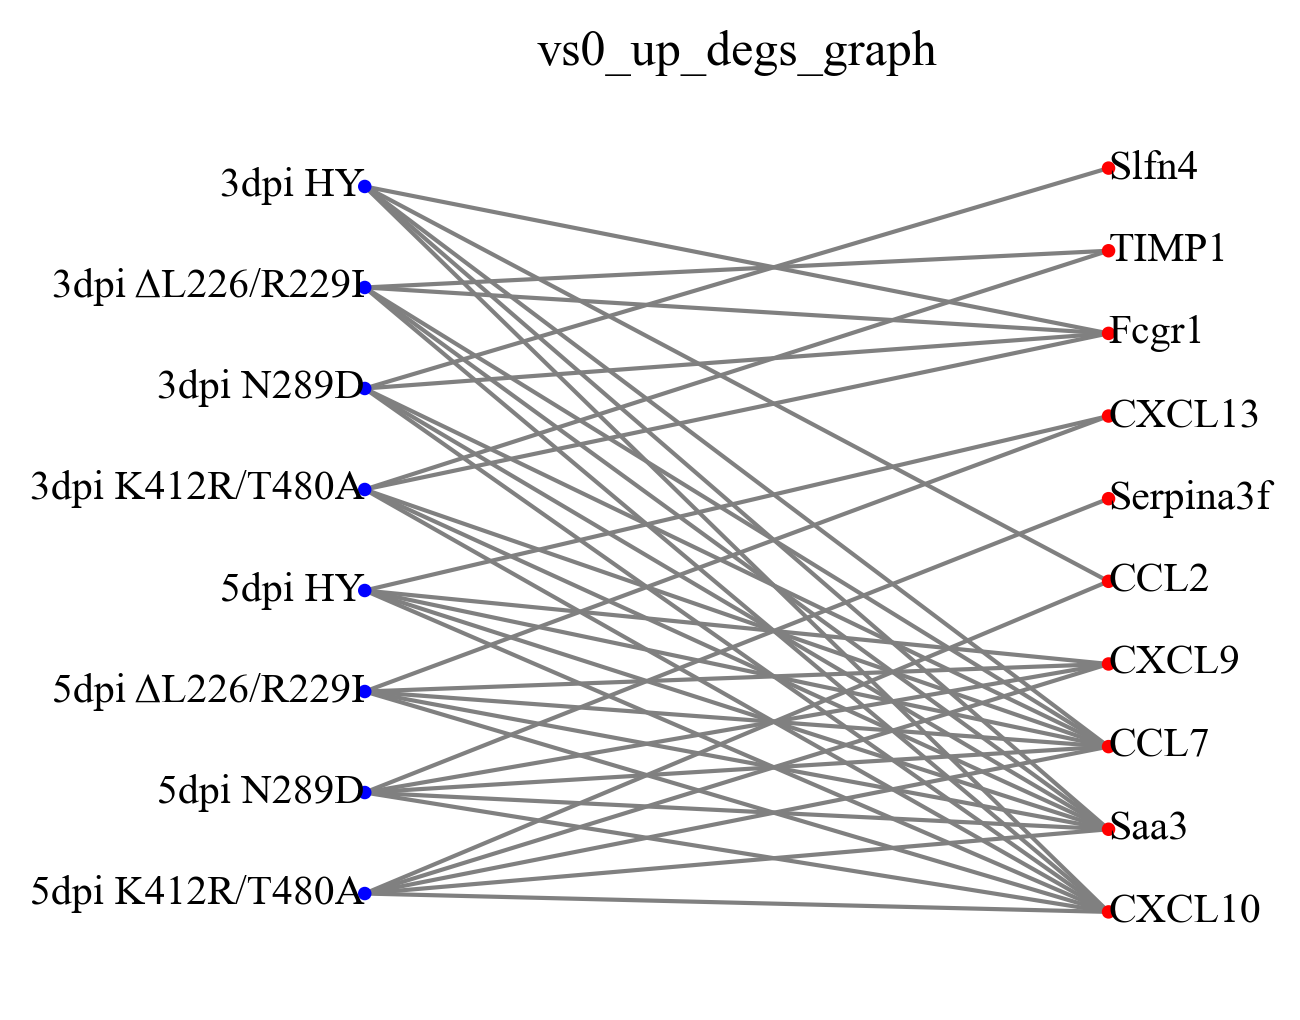

In [17]:
G = nx.Graph()

for key, values in data.items():
    for value in values:
        G.add_edge(key, value)

left_nodes = list(data.keys())
right_nodes = []
for sublist in data.values():
    for item in sublist:
        if item not in right_nodes:
            right_nodes.append(item)

pos = {}

left_vertical_spacing = 1 / (len(left_nodes) + 1)
left_y_pos_counter = left_vertical_spacing
right_vertical_spacing = 1 / (len(right_nodes) + 1)
right_y_pos_counter = right_vertical_spacing

for node in G.nodes():
    if node in data.keys():
        pos[node] = (1, left_y_pos_counter)
        left_y_pos_counter += left_vertical_spacing
    else:
        pos[node] = (2, right_y_pos_counter)
        right_y_pos_counter += right_vertical_spacing

color_map = ['blue' if node in data.keys() else 'red' for node in G]

plt.figure(figsize=(3, 3), dpi=300)

nx.draw(G, pos, with_labels=False, node_color=color_map, edge_color='gray', node_size=5, font_size=10)

for node, (x, y) in pos.items():
    if node in data.keys():
        horizontalalignment='right'
    else:
        horizontalalignment='left'

    text = degs_rename[node] if node in degs_rename else node

    plt.text(x, y, s=text, horizontalalignment=horizontalalignment, verticalalignment='center')

plt.title('vs0_up_degs_graph')
plt.savefig(f'vs0_up_degs_graph.pdf', bbox_inches='tight')
plt.show()


In [ ]:
for vs in ['0', 'HY']:
    for day_post_infection in [3, 5]:
        if vs == 'HY':
            sample_list = ['N289D', 'KT', 'T7']
        elif str(vs) == '0':
            sample_list = ['HY', 'N289D', 'KT', 'T7']
        for sample in sample_list:
            
            degs_result_path = f'vs{vs}/{day_post_infection}dpi_{sample}_vs_{day_post_infection}dpi_{vs}.DE_result'
            degs_result = pd.read_csv(degs_result_path, index_col=0)
            degs_result = degs_result.sort_values('logFC', ascending=False)
            sample_name = f'{day_post_infection}dpi_{sample}'
            for name_0, name_1 in {'KT': 'K412R/T480A', 'T7': 'ΔL226/R229I',}.items():
                sample_name = sample_name.replace(name_0, name_1)
            
            n = 5
            degs_result['top'] = 0
            for i in degs_result[-n:].index:
                degs_result.loc[i, 'top'] = 1
            for i in degs_result[:n].index:
                degs_result.loc[i, 'top'] = 1
            
            
            for gene_id in degs_gene_df[vs].index:
                if gene_id in degs_result.index.tolist():
                    logFC = degs_result.loc[gene_id, 'logFC']
                    degs_gene_df[vs].loc[gene_id, sample_name] = logFC
                

            print(f'{sample_name}: {len(degs_result)}')

In [4]:
log2fc = {}
log2fc['0'] = pd.read_csv('lof2FC_vs0.csv', index_col=0)
log2fc['HY'] = pd.read_csv('lof2FC_vsHY.csv', index_col=0)

tpm_df = pd.read_csv('TPM.csv', index_col=0)
fpkm_df = pd.read_csv('FPKM.csv', index_col=0)

In [12]:
log2fc['HY']

,3dpi_N289D,5dpi_N289D,3dpi_K412R/T480A,5dpi_K412R/T480A,3dpi_ΔL226/R229I,5dpi_ΔL226/R229I
ENSMUSG00000041616,NaN,NaN,6.418925,NaN,2.817598,NaN
ENSMUSG00000059824,3.289230,2.803158,3.725397,3.175889,2.889248,2.133605
ENSMUSG00000041476,NaN,0.884328,3.631081,NaN,1.721192,-0.380173
ENSMUSG00000051747,-0.448749,1.683709,3.572679,-0.456576,1.560369,2.011153
ENSMUSG00000015854,0.431371,-1.775069,3.388503,NaN,1.804959,NaN
...,...,...,...,...,...,...
ENSMUSG00000020811,-0.461740,-0.149318,-0.163502,0.320932,-0.730442,-2.070635
ENSMUSG00000076532,NaN,NaN,-0.424537,NaN,1.141713,-2.194740
ENSMUSG00000027314,0.299414,-0.579781,0.175174,-0.099837,-0.233179,-2.327571
ENSMUSG00000028475,-0.617529,-1.001562,-0.643109,-0.883457,-0.081304,-2.749706


In [7]:
fpkm_gene_df = pd.DataFrame(columns=['geneid', 'symbol'])
for geneid in fpkm_df.index:
    if geneid in gene_info_df['From'].tolist():
        symbol = gene_info_df[gene_info_df['From'] == geneid]['symbol'].iloc[0]
        fpkm_gene_df = pd.concat([fpkm_gene_df, pd.DataFrame({'geneid': [geneid], 'symbol': [symbol]})], ignore_index=True)
fpkm_gene_df

,geneid,symbol
0,ENSMUSG00000051951,Xkr4
1,ENSMUSG00000025900,Rp1
2,ENSMUSG00000025902,Sox17
3,ENSMUSG00000102269,Gm7357
4,ENSMUSG00000103922,Gm6123
...,...,...
21865,ENSMUSG00000094874,LOC102633783
21866,ENSMUSG00000062783,Csprs
21867,ENSMUSG00000094799,LOC105242404
21868,ENSMUSG00000094915,LOC671917


In [89]:
fpkm_df_self = pd.read_csv('fpkm.log2.matrix', sep='\t', index_col=0)
for column in fpkm_df_self.columns:
    new_column = column.replace('KT', 'K412R/T480A').replace('T7', 'ΔL226/R229I')
    fpkm_df_self.rename(columns={column: new_column}, inplace=True)
fpkm_df_self

,3dpi_0,5dpi_0,3dpi_HY,5dpi_HY,3dpi_ΔL226/R229I,5dpi_ΔL226/R229I,3dpi_K412R/T480A,5dpi_K412R/T480A,3dpi_N289D,5dpi_N289D
ENSMUSG00000102693,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000064842,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000051951,0.010370,0.129302,0.045973,0.099475,0.013295,0.064096,0.102652,0.050408,0.020927,0.027729
ENSMUSG00000102851,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000103377,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000094431,0.000000,0.000000,0.000000,0.000000,0.000000,0.323866,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000094621,1.493944,0.772601,0.302128,0.227983,0.302338,1.717209,0.403773,0.000000,0.000000,0.665765
ENSMUSG00000098647,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000096730,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


/Users/chenrujian/miniconda3/lib/python3.11/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)


vsHY: 751


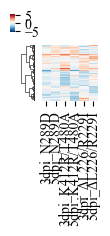

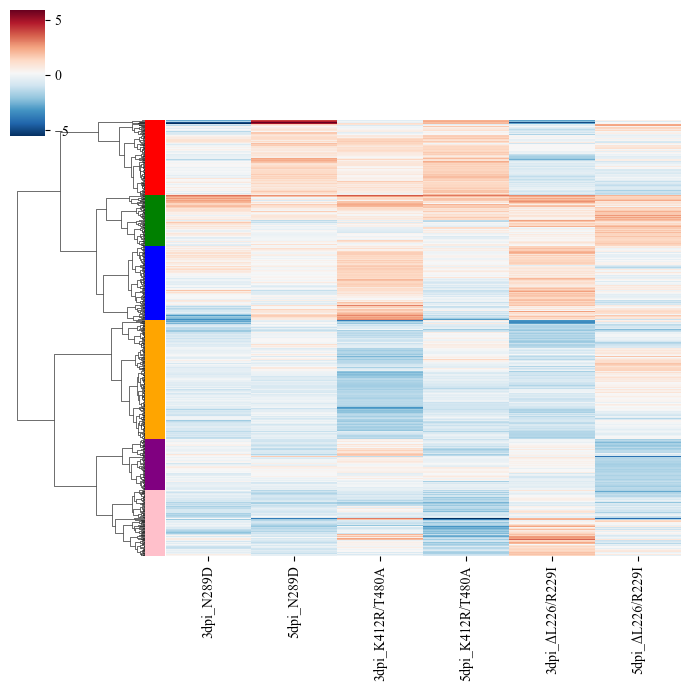

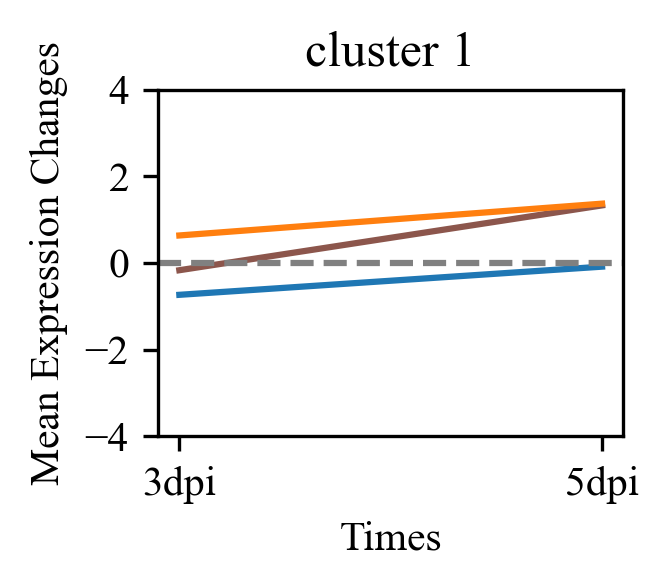

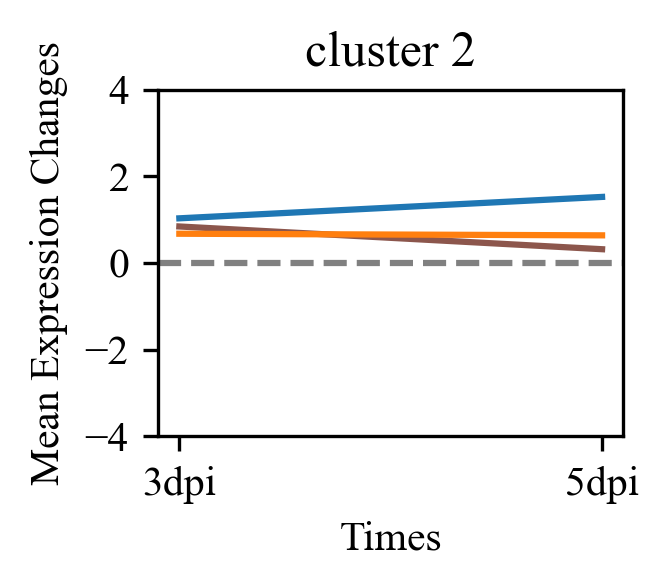

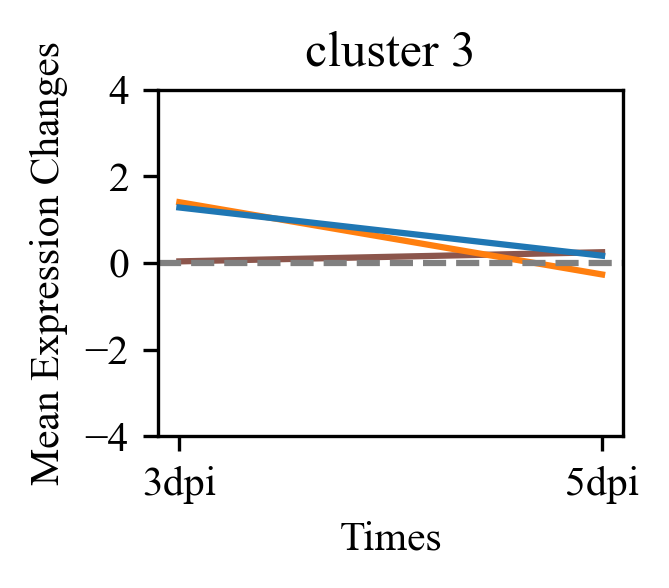

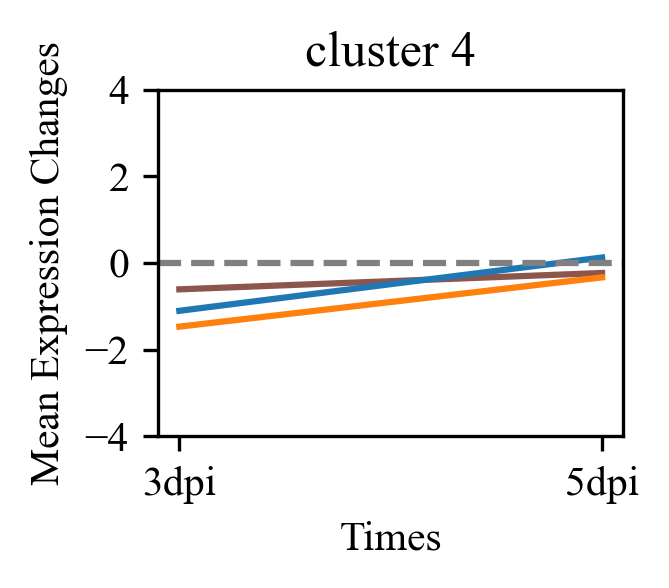

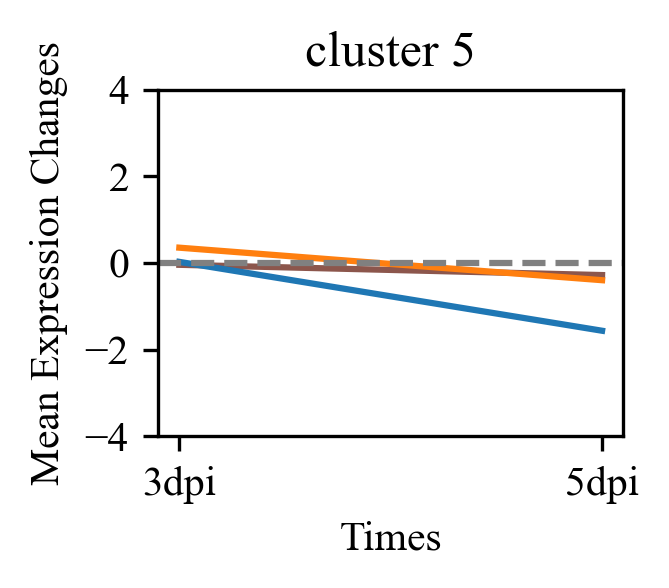

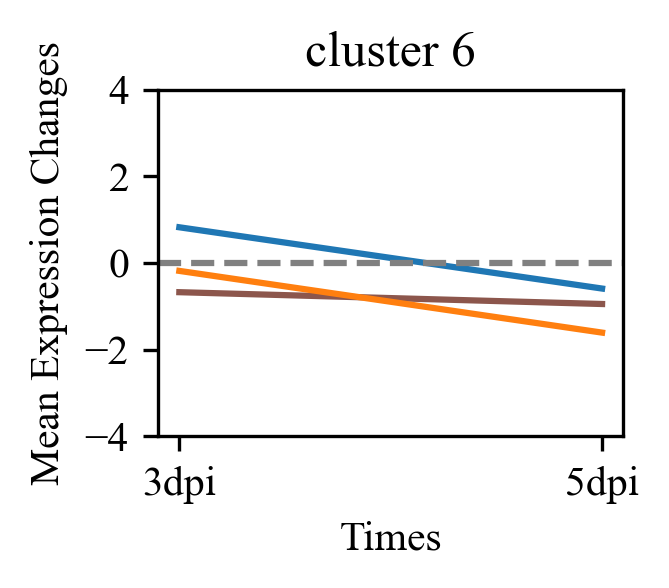

In [43]:
# clustermap

vs = 'HY'

gene_df = degs_gene_df[vs].copy()

gene_df = gene_df.dropna()

save_path = f'DEGs_cluster/vs{vs}_DEGs'

sample_list = []
for column in gene_df.columns.tolist():
    if column not in ['cluster', 'color']:
        sample_list.append(column)

gene_df = plot_clustermap(gene_df = gene_df,
                sample_list = sample_list, 
                save_path = save_path,
                cmap='RdBu_r',
                cluster_num=6,
                method='ward',
                figsize=(7, 7))

print(f'vs{vs}: {len(gene_df)}')


sample_list = []
for column in gene_df.columns.tolist():
    if column not in ['cluster', 'color']:
        sample = column.split('_')[1]
        if sample not in sample_list:
            sample_list.append(sample)

for cluster_id in sorted(gene_df['cluster'].unique()):
    gene_df_cluster = gene_df.loc[gene_df['cluster']==cluster_id]

    t_color = {'HY': '#2BA02B', 'ΔL226/R229I': '#1F77B4', 'K412R/T480A':'#FF7F0F', 'N289D':'#8C564C'}

    plt.figure(dpi=300, figsize=(2, 1.5))
    for sample in sample_list:
        mean_logFC_3dpi = gene_df_cluster[f'3dpi_{sample}'].mean()
        mean_logFC_5dpi = gene_df_cluster[f'5dpi_{sample}'].mean()
        plt.plot(['3dpi', '5dpi'], [mean_logFC_3dpi, mean_logFC_5dpi], label=sample, color=t_color[sample])
    
    plt.title(f'cluster {int(cluster_id)}')
    plt.ylabel('Mean Expression Changes')
    plt.ylim(-4, 4)
    plt.xlabel('Times')
    plt.axhline(y=0, color='gray', linestyle='--')
    #plt.legend()
    plt.savefig(f'{save_path}_cluster{int(cluster_id)}.png', bbox_inches='tight')
    plt.savefig(f'{save_path}_cluster{int(cluster_id)}.pdf', bbox_inches='tight')
    plt.show()

In [805]:
gene_df

,3dpi_HY,3dpi_N289D,3dpi_K412R/T480A,3dpi_ΔL226/R229I,5dpi_HY,5dpi_N289D,5dpi_K412R/T480A,5dpi_ΔL226/R229I,cluster,color
ENSMUSG00000034855,9.007939,8.658302,7.049521,8.119240,7.982530,7.457209,7.595400,9.085749,3.0,blue
ENSMUSG00000040026,7.586815,8.719679,8.351299,8.957037,8.027252,7.477941,7.204291,8.305001,3.0,blue
ENSMUSG00000035373,7.360903,7.415533,5.939247,6.568235,6.757433,6.167620,7.033454,8.169243,3.0,blue
ENSMUSG00000015947,7.138328,6.930047,6.202611,6.849985,4.936855,4.936546,4.742902,5.623501,3.0,blue
ENSMUSG00000035385,7.098593,6.880741,5.417635,6.378940,5.803752,4.913792,5.519593,6.388678,3.0,blue
...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000024922,-0.438591,-0.911759,-0.946372,-0.563413,-1.150616,-0.942637,-0.849227,-2.283265,1.0,red
ENSMUSG00000064284,-1.170200,-1.076702,-0.830797,-1.062770,-0.692596,-0.629748,-0.376133,-2.363348,1.0,red
ENSMUSG00000027524,-0.776554,-0.653585,-0.384940,-0.588601,-1.214254,-0.863779,-0.873855,-2.740749,1.0,red
ENSMUSG00000090509,-0.926473,-1.254011,-0.925241,-0.735662,-1.129675,-1.304166,-1.104667,-2.876962,1.0,red


In [85]:
def plot_volcano(de_result, title, degs_rename=0):
    
    plt.figure(figsize=(1.8, 1.8), dpi = 300)
    text_list = []
    for geneid in de_result.index:

        logFC = de_result.loc[geneid, 'logFC']
        PValue = de_result.loc[geneid, 'PValue']
        is_top = int(de_result.loc[geneid, 'top'])
        
        PValue = -np.log10(PValue)

        if geneid in id2genename:
            gene_name = id2genename[geneid]
        else:
            gene_name = geneid

        if (degs_rename != 0) and (gene_name in degs_rename):
            gene_name = degs_rename[gene_name]
        
        if (is_top == 1):
            text_list.append(plt.text(logFC, PValue, gene_name, fontsize=8))
        if logFC > 1:
            color = 'red'
        elif logFC < -1:
            color = 'blue'
        else:
            color = 'gray'
        
        plt.scatter(x = logFC, y = PValue, s = 10, alpha = 0.5, color = color)

    plt.axhline(y=-np.log10(0.05), color='gray', linestyle='--')
    plt.axvline(x=1, color='gray', linestyle='--')
    plt.axvline(x=-1, color='gray', linestyle='--')
        
    adjust_text(text_list)
    plt.title(title)
    plt.xlabel('log2FC')
    plt.ylabel('-log10 (PValue)')
    plt.xticks([-4,-1, 0, 1, 4], ['-4', '-1', '0', '1', '4'])
    plt.savefig(f'DEGs_volcano/{title.replace("/", "_")}.pdf', bbox_inches='tight')
    plt.show()

In [553]:
vs = '0'
day_post_infection = 5
sample = 'N289D'
degs_result_path = f'vs{vs}/{day_post_infection}dpi_{sample}_vs_{day_post_infection}dpi_{vs}.DE_result'
degs_result = pd.read_csv(degs_result_path, index_col=0)
degs_result

,sampleA,sampleB,logFC,logCPM,PValue,FDR,top,symbol
ENSMUSG00000040026,5dpi_N289D,5dpi_0,7.477941,8.267380,7.779217e-18,6.149224e-14,1,Saa3
ENSMUSG00000034855,5dpi_N289D,5dpi_0,7.457209,8.282350,8.700090e-18,6.149224e-14,1,Cxcl10
ENSMUSG00000029417,5dpi_N289D,5dpi_0,6.774344,6.948748,1.190403e-15,5.609177e-12,1,Cxcl9
ENSMUSG00000035373,5dpi_N289D,5dpi_0,6.167620,6.064828,8.672293e-14,3.064788e-10,1,Ccl7
ENSMUSG00000066363,5dpi_N289D,5dpi_0,5.753101,6.710094,8.964955e-13,2.276090e-09,1,Serpina3f
...,...,...,...,...,...,...,...,...
ENSMUSG00000079355,5dpi_N289D,5dpi_0,-2.994921,2.797910,3.738568e-05,3.361891e-03,1,Ackr4
ENSMUSG00000057606,5dpi_N289D,5dpi_0,-3.055200,4.234803,1.932369e-05,2.023405e-03,1,Colq
ENSMUSG00000020427,5dpi_N289D,5dpi_0,-3.107364,6.969663,1.146098e-05,1.327971e-03,1,Igfbp3
ENSMUSG00000003545,5dpi_N289D,5dpi_0,-3.717168,5.254865,3.927368e-07,8.674574e-05,1,Fosb


3dpi_HY: 2342


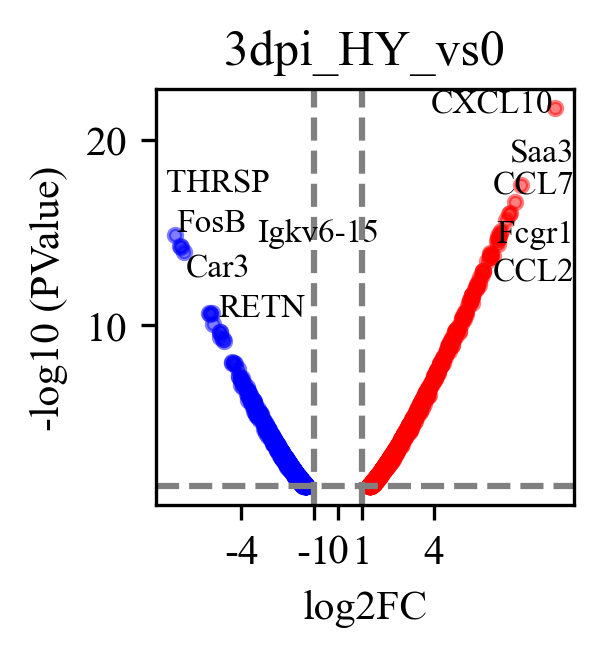

3dpi_K412R/T480A: 1563


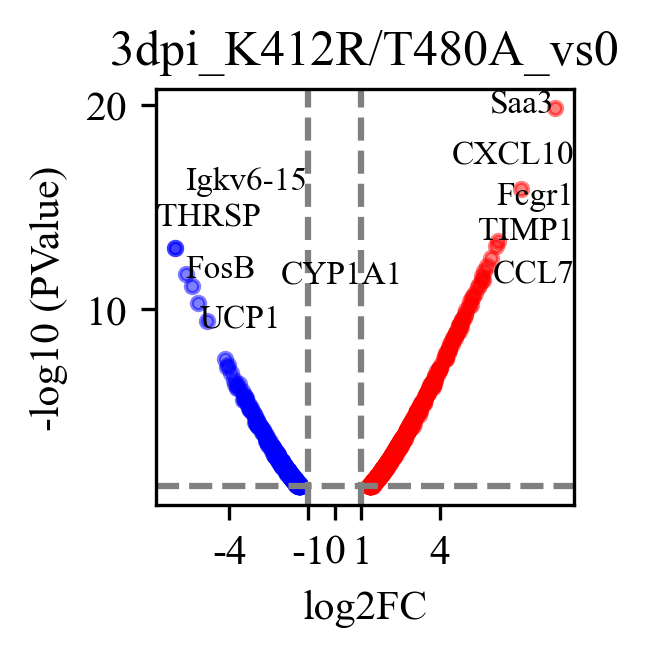

3dpi_N289D: 2255


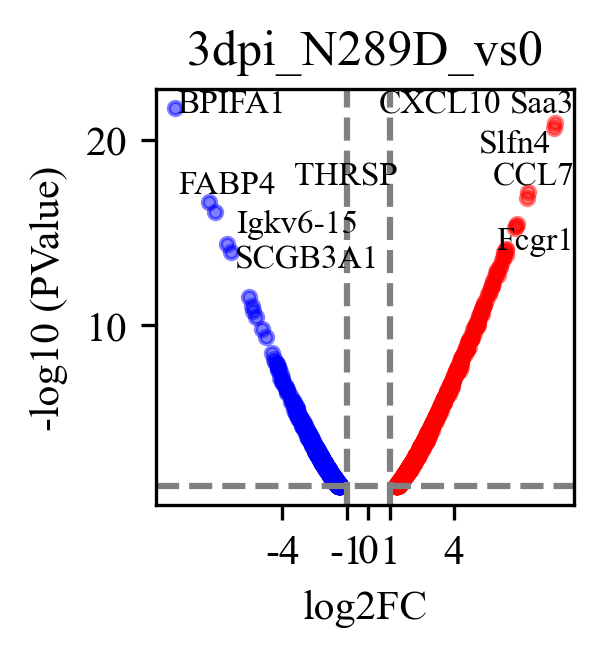

3dpi_ΔL226/R229I: 2152


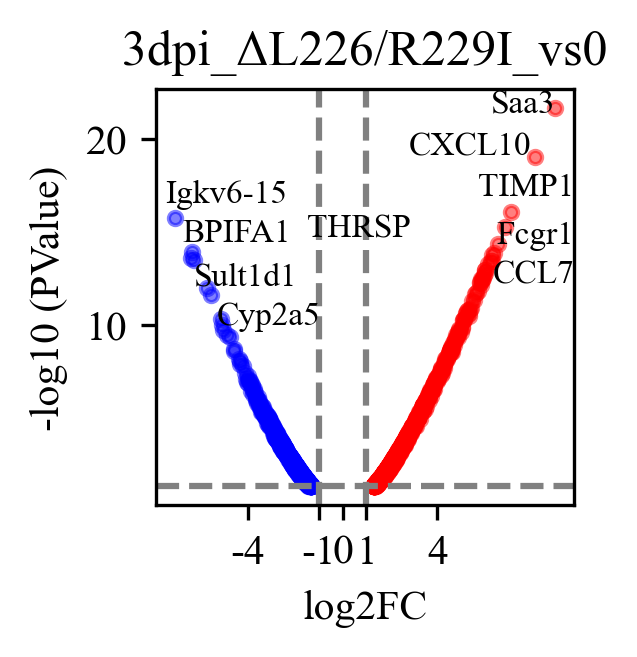

5dpi_HY: 1404


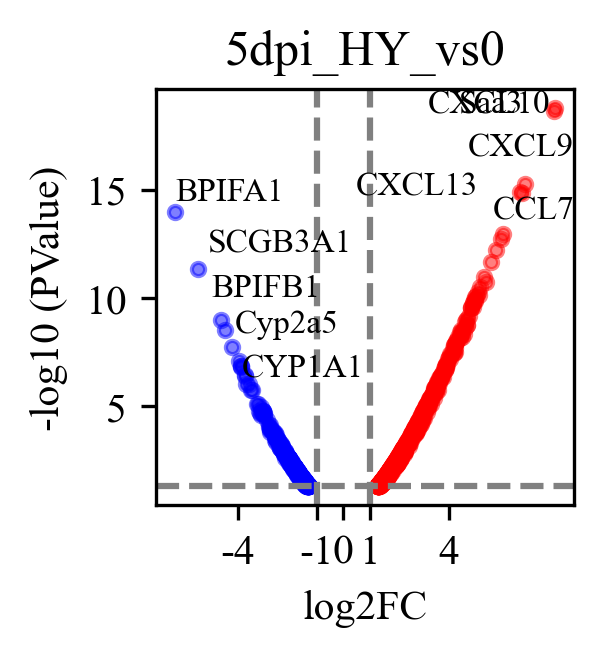

5dpi_K412R/T480A: 989


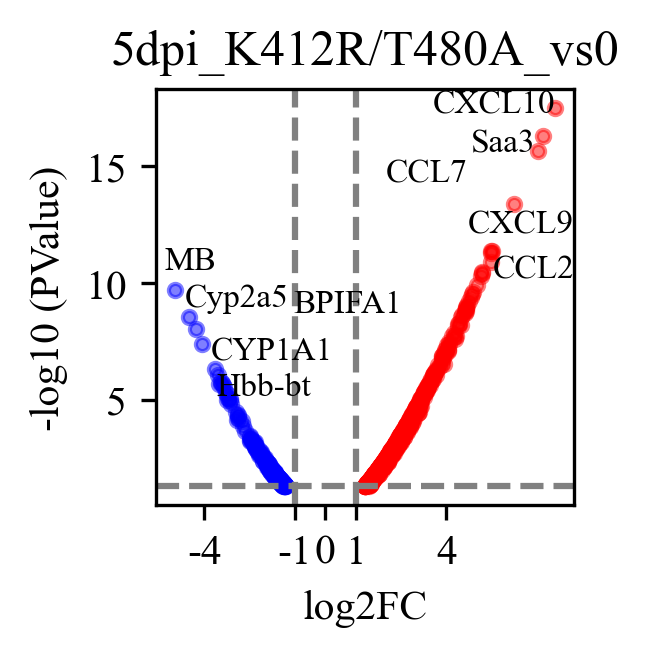

5dpi_N289D: 1116


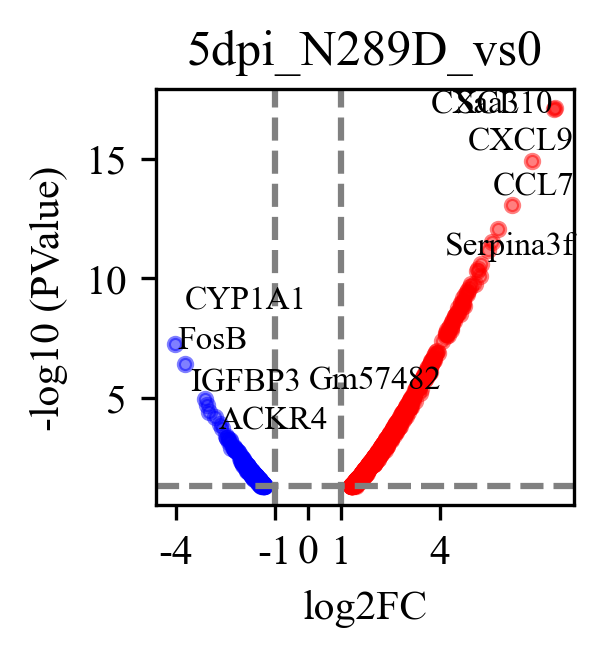

5dpi_ΔL226/R229I: 2217


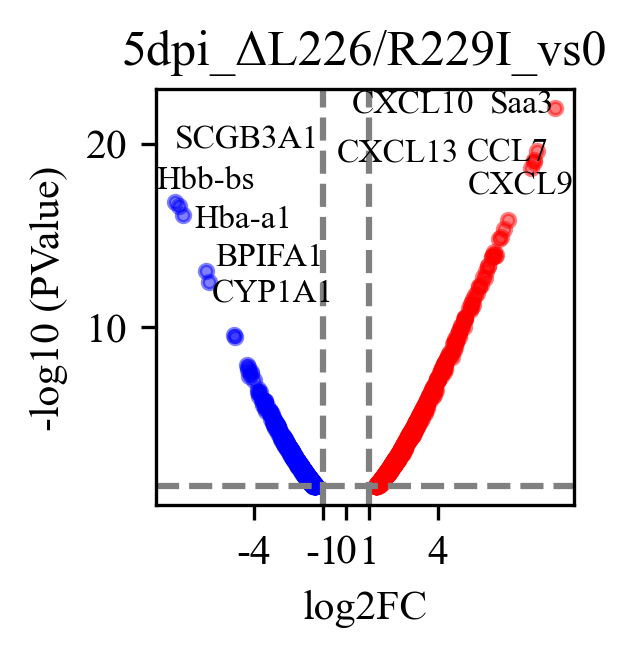

3dpi_K412R/T480A: 339


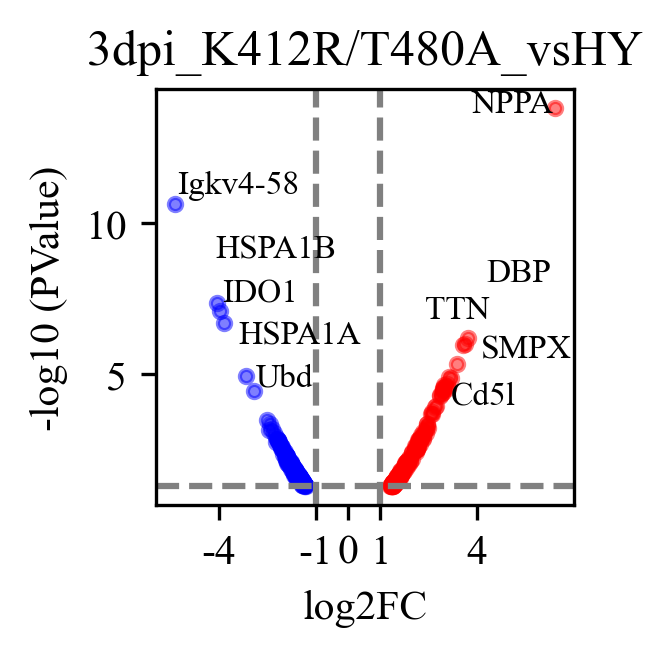

3dpi_N289D: 94


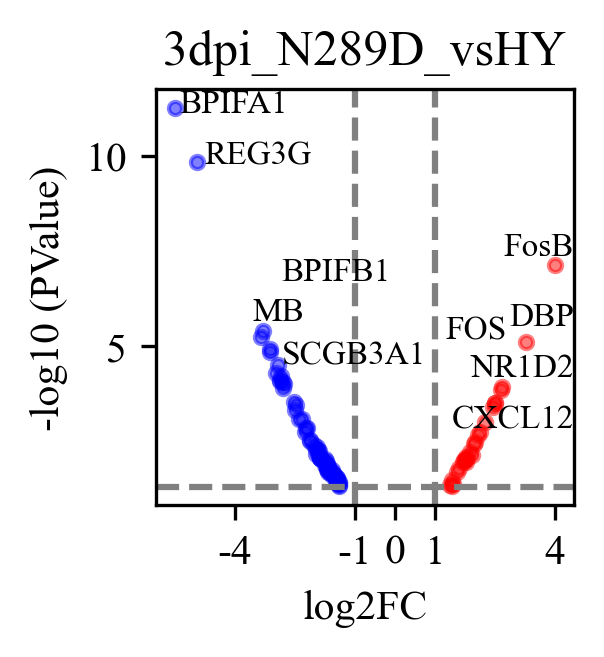

3dpi_ΔL226/R229I: 278


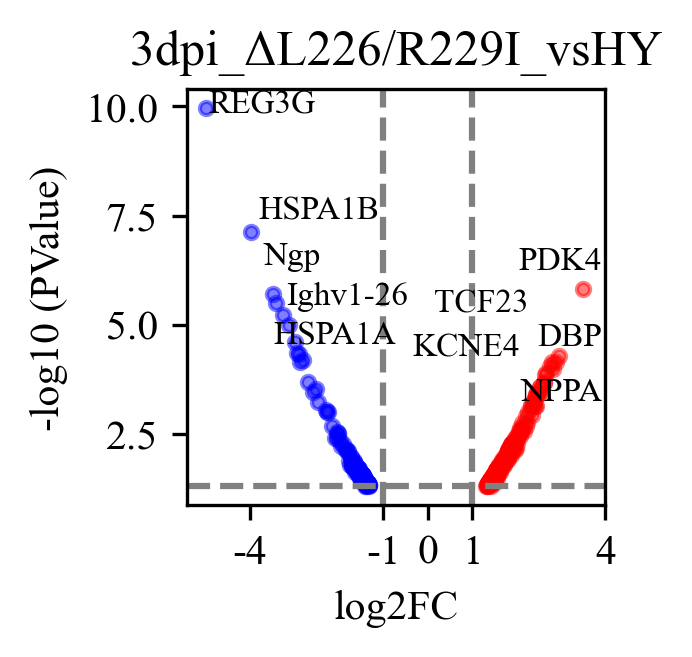

5dpi_K412R/T480A: 258


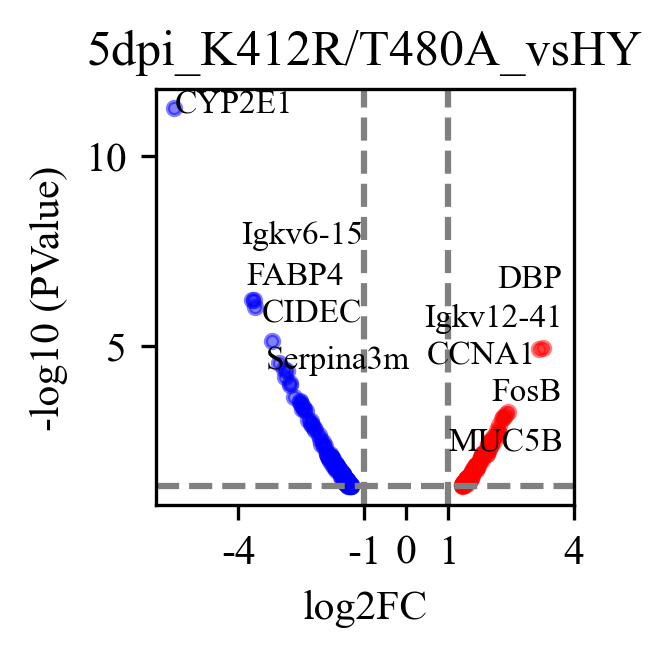

5dpi_N289D: 131


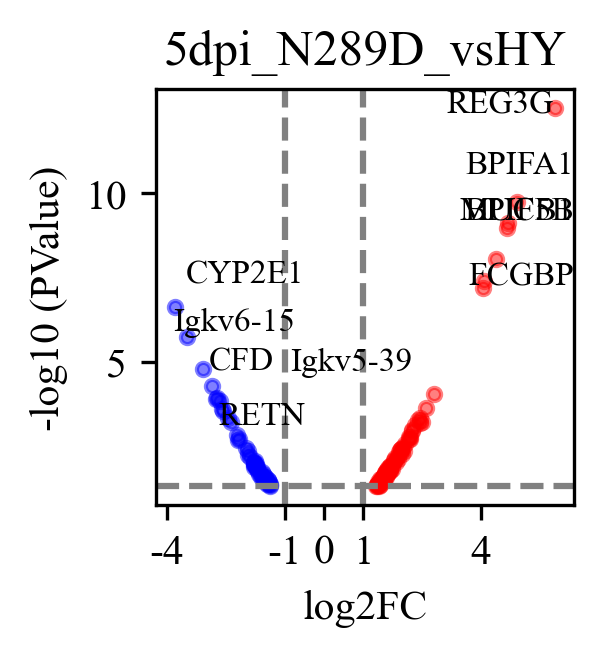

5dpi_ΔL226/R229I: 257


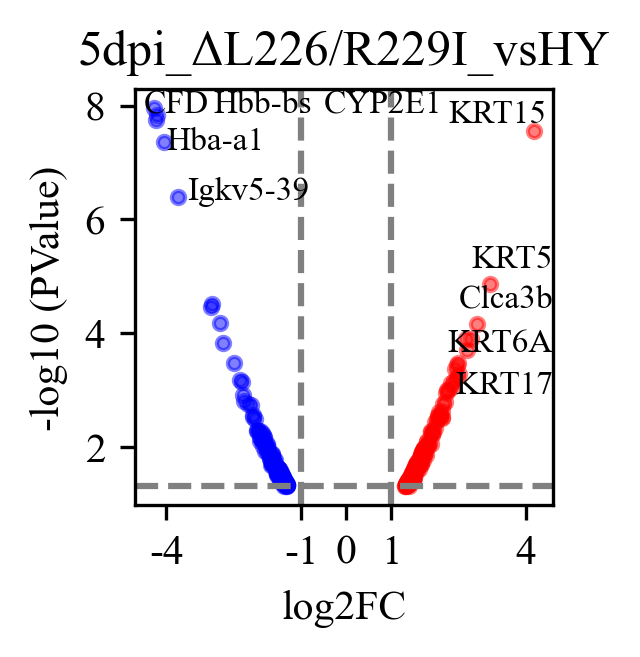

In [86]:
for vs in ['0', 'HY']:
    for day_post_infection in [3, 5]:
        if vs == 'HY':
            sample_list = ['KT', 'N289D', 'T7']
        elif str(vs) == '0':
            sample_list = ['HY', 'KT', 'N289D', 'T7']
        for sample in sample_list:
            
            degs_result_path = f'vs{vs}/{day_post_infection}dpi_{sample}_vs_{day_post_infection}dpi_{vs}.DE_result'
            degs_result = pd.read_csv(degs_result_path, index_col=0)
            degs_result = degs_result.sort_values('logFC', ascending=False)
            
            degs_result = degs_result.loc[degs_result['PValue'] <= 0.05]
            degs_result = degs_result.loc[abs(degs_result['logFC']) >= 1]

            sample_name = f'{day_post_infection}dpi_{sample}'
            for name_0, name_1 in {'KT': 'K412R/T480A', 'T7': 'ΔL226/R229I',}.items():
                sample_name = sample_name.replace(name_0, name_1)

            n = 5
            degs_result['top'] = 0
            for i in degs_result[-n:].index:
                degs_result.loc[i, 'top'] = 1
            for i in degs_result[:n].index:
                degs_result.loc[i, 'top'] = 1

            print(f'{sample_name}: {len(degs_result)}')

            plot_volcano(degs_result, title=f'{sample_name}_vs{vs}',  degs_rename=degs_rename)

In [883]:
pd.read_csv('featurecounts.csv')[['Geneid', 'Length', '5dpi_N289D',
       '3dpi_KT', '5dpi_HY', '3dpi_HY', '5dpi_T7', '5dpi_0', '3dpi_T7',
       '3dpi_0', '3dpi_N289D', '5dpi_KT']].to_csv('featurecounts_clean.csv', index=False)

In [884]:
pd.read_csv('featurecounts_clean.csv')

,Geneid,Length,5dpi_N289D,3dpi_KT,5dpi_HY,3dpi_HY,5dpi_T7,5dpi_0,3dpi_T7,3dpi_0,3dpi_N289D,5dpi_KT
0,ENSMUSG00000102693,1070,0,0,0,0,0,0,0,0,0,0
1,ENSMUSG00000064842,110,0,0,0,0,0,0,0,0,0,0
2,ENSMUSG00000051951,6094,5,23,21,7,11,20,2,2,4,10
3,ENSMUSG00000102851,480,0,0,0,0,0,0,0,0,0,0
4,ENSMUSG00000103377,2819,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
47724,ENSMUSG00000094431,100,0,0,0,0,1,0,0,0,0,0
47725,ENSMUSG00000094621,121,3,2,1,1,11,3,1,10,0,0
47726,ENSMUSG00000098647,99,0,0,0,0,0,0,0,0,0,0
47727,ENSMUSG00000096730,3077,0,0,0,0,0,0,0,0,0,0


In [ ]:
enrichment_result_df = pd.DataFrame(columns=['vs', 'method', 'day_post_infection', 'sample', 'description', 'logPValue'])

n = 5
for vs in ['HY']:#, '0']:
    for enrichment_method in ['BP', 'CC', 'MF', 'KEGG']:
        for day_post_infection in [3, 5]:
            if vs == 'HY':
                sample_list = ['KT', 'N289D', 'T7']
            elif str(vs) == '0':
                sample_list = ['HY', 'KT', 'N289D', 'T7']
            for sample in sample_list:

                sample_name = sample
                for name_0, name_1 in {'KT': 'K412R/T480A', 'T7': 'ΔL226/R229I',}.items():
                    sample_name = sample_name.replace(name_0, name_1)
            
                enrichment_result_path = f'DEGs_GO_KEGG/{day_post_infection}dpi_{sample}_vs{vs}_{enrichment_method}.csv'
                enrichment_result = pd.read_csv(enrichment_result_path, index_col=0)

                enrichment_result = pd.concat([enrichment_result.head(n), enrichment_result.tail(n)]).reset_index(drop=True)
                enrichment_result = enrichment_result.iloc[::-1].reset_index(drop=True)

                for i in enrichment_result.index:
                    description = enrichment_result.loc[i, 'Description']
                    logPValue = enrichment_result.loc[i, 'logPValue']

                    df_line = {'vs': [vs], 
                               'method': [enrichment_method], 
                               'day_post_infection': [day_post_infection], 
                               'sample': [sample],
                               'description': [description], 
                               'logPValue': [logPValue]}

                    enrichment_result_df = pd.concat([enrichment_result_df, pd.DataFrame(df_line)], ignore_index=True)

                plt.figure(dpi=300, figsize=(2, 3))
                y_ticks = []
                for i in enrichment_result.index:
                    description = enrichment_result.loc[i, 'Description']
                    logPValue = enrichment_result.loc[i, 'logPValue']
                    y_ticks.append(description)
                    if logPValue < 0:
                        color='blue'
                    elif logPValue > 0:
                        color='red'
                    plt.barh(i, logPValue, color=color)
                plt.xlabel('-log10 (P Value)')
                plt.yticks(range(len(enrichment_result)), y_ticks)

                plt.gca().spines['right'].set_visible(False)
                plt.gca().spines['left'].set_visible(False)
                plt.gca().spines['top'].set_visible(False)
                plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
                plt.title(f'{day_post_infection}dpi {sample_name}')
                plt.savefig(f'DEGs_GO_KEGG/{enrichment_method}/{day_post_infection}dpi_{sample}_vs{vs}.pdf', bbox_inches='tight')
                plt.show()
                

In [776]:
df_genes = pd.DataFrame(columns=['geneid', 'symbol'])

for vs in ['0', 'HY']:
    for day_post_infection in [3, 5]:
        if vs == 'HY':
            sample_list = ['KT', 'N289D', 'T7']
        elif str(vs) == '0':
            sample_list = ['HY', 'KT', 'N289D', 'T7']
        for sample in sample_list:

            degs_result_path = f'vs{vs}/{day_post_infection}dpi_{sample}_vs_{day_post_infection}dpi_{vs}.DE_result'
            degs_result = pd.read_csv(degs_result_path, index_col=0)
            degs_result = degs_result.sort_values('logFC', ascending=False)

            degs_result = degs_result.loc[degs_result['PValue'] <= 0.05]

            degs_result = degs_result.loc[degs_result['symbol']!='-']

            sample_name = f'{day_post_infection}dpi_{sample}'
            for name_0, name_1 in {'KT': 'K412R/T480A', 'T7': 'ΔL226/R229I',}.items():
                sample_name = sample_name.replace(name_0, name_1)

            n = 5
            degs_result['top'] = 0
            for i in degs_result[-n:].index:
                degs_result.loc[i, 'top'] = 1
            for i in degs_result[:n].index:
                degs_result.loc[i, 'top'] = 1

            print(f'{sample_name}: {len(degs_result)}')
            
            for geneid in degs_result.index:
                symbol = degs_result.loc[geneid, 'symbol']
                df_genes = pd.concat([df_genes, pd.DataFrame({'geneid': [geneid], 'symbol': [symbol]})], ignore_index=True)

3dpi_HY: 2342
3dpi_K412R/T480A: 1563
3dpi_N289D: 2255
3dpi_ΔL226/R229I: 2152
5dpi_HY: 1404
5dpi_K412R/T480A: 989
5dpi_N289D: 1116
5dpi_ΔL226/R229I: 2217
3dpi_K412R/T480A: 321
3dpi_N289D: 93
3dpi_ΔL226/R229I: 264
5dpi_K412R/T480A: 250
5dpi_N289D: 129
5dpi_ΔL226/R229I: 239


In [777]:
df_genes

,geneid,symbol
0,ENSMUSG00000034855,Cxcl10
1,ENSMUSG00000040026,Saa3
2,ENSMUSG00000035373,Ccl7
3,ENSMUSG00000015947,Fcgr1
4,ENSMUSG00000035385,Ccl2
...,...,...
15329,ENSMUSG00000076569,Igkv5-39
15330,ENSMUSG00000069919,Hba-a1
15331,ENSMUSG00000052305,Hbb-bs
15332,ENSMUSG00000025479,Cyp2e1


In [674]:
enrichment_result_df.loc[enrichment_result_df['method']=='KEGG']['description'].value_counts()

description
IL-17 signaling pathway                                          5
PPAR signaling pathway                                           4
Hypertrophic cardiomyopathy                                      4
Cardiac muscle contraction                                       4
Dilated cardiomyopathy                                           4
Viral protein interaction with cytokine and cytokine receptor    3
Adrenergic signaling in cardiomyocytes                           3
African trypanosomiasis                                          2
Circadian rhythm                                                 2
Malaria                                                          2
Circadian entrainment                                            2
Cytokine-cytokine receptor interaction                           2
Complement and coagulation cascades                              1
Renin secretion                                                  1
Metabolism of xenobiotics by cytochrome P450      

In [ ]:
# clustermap

gene_str = 'Mapk15/Cxcl3/Il17f/Il17d/Il17c/Mapk4/Il17rc/Il25/Srsf1/Traf3ip2/Muc5b/Tradd/Tab2/Tab3/Anapc5/Il17re/Gsk3b/Ikbke/Tbk1/Il17b/Il17rb/Mapk6/Usp25/Mapk12/Mapk9/Mapk8/Mapk3/Mapk14/Mapk13/Mapk10/Mapk1/Map3k7/Mapk7/Traf6/Traf5/Traf4/Traf3/Traf2/Hsp90b1/Tnfaip3/Tnf/Cxcl5/Cxcl2/Ccl7/Ccl20/Ccl2/Ccl17/Ccl12/Ccl11/S100a9/S100a8/Rela/Ptgs2/Mapk11/Nfkbia/Nfkb1/Muc5ac/Mmp9/Mmp3/Mmp13/Lcn2/Jund/Jun/Il6/Il5/Il4/Il1b/Il17ra/Il17a/Il13/Ikbkg/Ikbkb/Ifng/Cxcl10/Elavl1/Hsp90aa1/Hsp90ab1/Cxcl1/Fosl1/Fosb/Fos/Fadd/Csf3/Csf2/Chuk/Cebpb/Casp8/Casp3'

gene_df = fpkm_df_self.loc[fpkm_df_self.index.isin(gene_info_df.loc[gene_info_df['symbol'].isin(gene_str.split('/'))]['From'])].copy()

gene_df = gene_df.dropna()[[
    '3dpi_HY', '3dpi_N289D', '3dpi_K412R/T480A', '3dpi_ΔL226/R229I',
    '5dpi_HY', '5dpi_N289D', '5dpi_K412R/T480A', '5dpi_ΔL226/R229I'
]]

def cal_zscore(df):
    for i in df.index:
        df.loc[i] = (df.loc[i] - df.loc[i].mean()) / df.loc[i].std()
    return df

gene_df = cal_zscore(gene_df)

save_path = f'IL-17_clustermap'

sample_list = []
for column in gene_df.columns.tolist():
    if column not in ['cluster', 'color']:
        sample_list.append(column)

gene_df = plot_clustermap(gene_df = gene_df,
                sample_list = sample_list, 
                save_path = save_path,
                cmap='coolwarm',
                cluster_num=4,
                method='ward',
                figsize=(7, 7))


sample_list = []
for column in gene_df.columns.tolist():
    if column not in ['cluster', 'color']:
        sample = column.split('_')[1]
        if sample not in sample_list:
            sample_list.append(sample)

for cluster_id in sorted(gene_df['cluster'].unique()):
    gene_df_cluster = gene_df.loc[gene_df['cluster']==cluster_id]

    t_color = {'HY': '#2BA02B', 'ΔL226/R229I': '#1F77B4', 'K412R/T480A':'#FF7F0F', 'N289D':'#8C564C'}

    plt.figure(dpi=300, figsize=(2, 1.5))
    for sample in sample_list:
        mean_logFC_3dpi = gene_df_cluster[f'3dpi_{sample}'].mean()
        mean_logFC_5dpi = gene_df_cluster[f'5dpi_{sample}'].mean()
        plt.plot(['3dpi', '5dpi'], [mean_logFC_3dpi, mean_logFC_5dpi], label=sample, color=t_color[sample])
    
    plt.title(f'cluster {int(cluster_id)}')
    plt.ylabel('Mean Expression Changes')
    plt.ylim(-4, 4)
    plt.xlabel('Times')
    plt.axhline(y=0, color='gray', linestyle='--')
    #plt.legend()
    plt.savefig(f'{save_path}_cluster{int(cluster_id)}.png', bbox_inches='tight')
    plt.savefig(f'{save_path}_cluster{int(cluster_id)}.pdf', bbox_inches='tight')
    plt.show()

In [106]:
il17_df_cluster2.loc[il17_df_cluster2.index.isin(log2fc['HY'].index)]

,3dpi_HY,3dpi_N289D,3dpi_K412R/T480A,3dpi_ΔL226/R229I,5dpi_HY,5dpi_N289D,5dpi_K412R/T480A,5dpi_ΔL226/R229I,cluster,color
ENSMUSG00000055170,-0.139944,-0.445969,-1.636874,-0.997146,0.637711,0.506444,0.656914,1.418864,2.0,green
ENSMUSG00000035373,0.724760,0.831151,-1.221155,-0.415466,-0.327533,-1.223896,0.046999,1.585141,2.0,green
ENSMUSG00000024912,0.022943,-0.478273,-0.694861,0.585991,0.214151,-0.836794,-0.905600,2.092442,2.0,green


In [123]:
il17_df_cluster2

,3dpi_HY,3dpi_N289D,3dpi_K412R/T480A,3dpi_ΔL226/R229I,5dpi_HY,5dpi_N289D,5dpi_K412R/T480A,5dpi_ΔL226/R229I,cluster,color
ENSMUSG00000041872,-0.370509,-0.713452,-0.120860,-1.477015,1.126765,-0.632423,0.875341,1.312153,2.0,green
ENSMUSG00000026029,0.832660,1.258678,-1.098118,-0.106618,-1.182487,-0.698387,-0.252821,1.247092,2.0,green
ENSMUSG00000042349,-0.062235,0.928853,-0.451500,-0.164042,-0.507253,-0.874463,-0.890948,2.021588,2.0,green
ENSMUSG00000027164,-0.279626,1.240177,-1.197722,-0.469938,0.236270,-1.039455,-0.096794,1.607088,2.0,green
ENSMUSG00000035476,-1.886944,0.163322,-0.086726,-0.519691,-0.141953,-0.011838,1.119093,1.364738,2.0,green
ENSMUSG00000028163,0.990435,0.475899,-1.506696,-1.380312,0.041574,-0.032345,0.149709,1.261736,2.0,green
ENSMUSG00000028284,-1.344068,-0.163570,0.230819,-1.631900,0.506948,0.613432,0.564037,1.224303,2.0,green
ENSMUSG00000002897,-0.856111,-0.149118,-0.380363,0.306183,0.376364,-0.905704,-0.565011,2.173759,2.0,green
ENSMUSG00000015755,-0.602820,-0.205265,-0.236063,-0.570977,-0.405630,-0.191814,-0.228569,2.441139,2.0,green
ENSMUSG00000055170,-0.139944,-0.445969,-1.636874,-0.997146,0.637711,0.506444,0.656914,1.418864,2.0,green


In [102]:
il17_df_cluster2 = gene_df.loc[gene_df['cluster']==2].copy()

gene_df = il17_df_cluster2

gene_df = cal_zscore(gene_df)

save_path = f'IL-17_clustermap'

sample_list = []
for column in gene_df.columns.tolist():
    if column not in ['cluster', 'color']:
        sample_list.append(column)

gene_df = plot_clustermap(gene_df = gene_df,
                sample_list = sample_list, 
                save_path = save_path,
                cmap='coolwarm',
                cluster_num=4,
                method='ward',
                figsize=(7, 7))

In [68]:
def plot_clustermap_for_genes(gene_str, save_path, vs, cluster_num, figsize=(8, 8), degs_rename=0):

    gene_list = []
    for gene_symbol in gene_str.split('/'):
        if gene_symbol in gene_info_df['symbol'].tolist():
            if gene_symbol not in gene_list:
                gene_list.append(gene_symbol)
        else:
            print(gene_symbol)
    gene_df = pd.DataFrame(index=gene_list)

    for day_post_infection in [3, 5]:
        if vs == 'HY':
            sample_list = ['N289D', 'KT', 'T7']
        elif str(vs) == '0':
            sample_list = ['HY', 'N289D', 'KT', 'T7']
        for sample in sample_list:
            degs_result_path = f'vs{vs}/{day_post_infection}dpi_{sample}_vs_{day_post_infection}dpi_{vs}.DE_result'
            degs_result = pd.read_csv(degs_result_path, index_col=0)
            degs_result = degs_result.sort_values('logFC', ascending=False)
            sample_name = f'{day_post_infection}dpi_{sample}'
            for name_0, name_1 in {'KT': 'K412R/T480A', 'T7': 'ΔL226/R229I',}.items():
                sample_name = sample_name.replace(name_0, name_1)

            n = 5
            degs_result['top'] = 0
            for i in degs_result[-n:].index:
                degs_result.loc[i, 'top'] = 1
            for i in degs_result[:n].index:
                degs_result.loc[i, 'top'] = 1

            print(f'{sample_name}: {len(degs_result)}')

            for symbol in gene_df.index:
                if symbol in degs_result['symbol'].tolist():
                    gene_df.loc[symbol, sample_name] = degs_result.loc[degs_result['symbol']==symbol, 'logFC'].iloc[0]

    gene_df = gene_df.dropna()

    sample_list = []
    for column in gene_df.columns.tolist():
        if column not in ['cluster', 'color']:
            sample_list.append(column)

    print(len(gene_df))

    if degs_rename != 0:
        gene_df['symbol_rename'] = ''
        for symbol in gene_df.index:
            if symbol not in degs_rename.keys():
                continue
            else:
                gene_df.loc[symbol, 'symbol_rename'] = degs_rename[symbol]
        gene_df = gene_df.set_index('symbol_rename')

    
    gene_df = plot_clustermap(gene_df = gene_df,
                    sample_list = sample_list, 
                    save_path = save_path,
                    cmap='coolwarm', 
                    cluster_num=cluster_num,
                    method='ward',
                    ylabel=1, figsize=figsize)
    
    return gene_df

3dpi_N289D: 14018
3dpi_K412R/T480A: 14129
3dpi_ΔL226/R229I: 14007
5dpi_N289D: 14304
5dpi_K412R/T480A: 14212
5dpi_ΔL226/R229I: 14032
20


/Users/chenrujian/miniconda3/lib/python3.11/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)


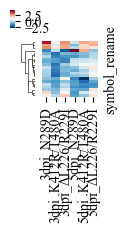

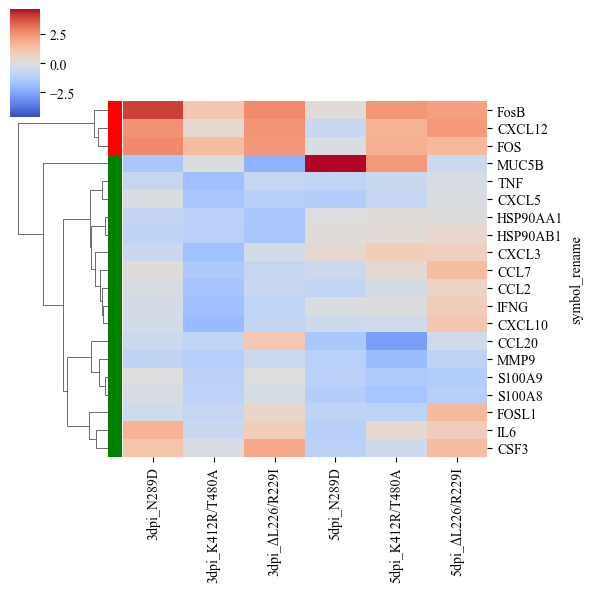

In [73]:
# IL-17 from vsHY KEGG

gene_str = 'Cxcl3/Muc5b/Mapk10/Tnf/Cxcl5/Cxcl2/Ccl7/Ccl20/Ccl2/S100a9/S100a8/Muc5ac/Mmp9/Il6/Ifng/Cxcl10/Hsp90aa1/Hsp90ab1/Fosl1/Fosb/Fos/Csf3'
pathway = 'IL17'
vs = 'HY'
save_path = f'vs{vs}_gene_{pathway}'

gene_df = plot_clustermap_for_genes(gene_str, save_path, vs, cluster_num=2, figsize=(6, 6), degs_rename=degs_rename)

3dpi_N289D: 14018
3dpi_K412R/T480A: 14129
3dpi_ΔL226/R229I: 14007
5dpi_N289D: 14304
5dpi_K412R/T480A: 14212
5dpi_ΔL226/R229I: 14032
15


/Users/chenrujian/miniconda3/lib/python3.11/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)


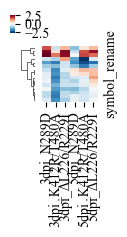

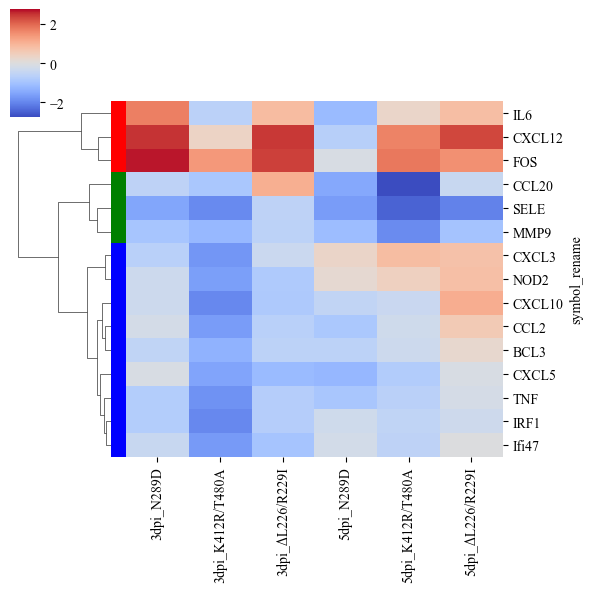

In [79]:
# TNF from vsHY KEGG

gene_str = 'Cxcl3/Nod2/Mapk10/Tnf/Sele/Cxcl5/Cxcl2/Ccl20/Ccl2/Mmp9/Irf1/Il6/Ifi47/Cxcl10/Fos/Bcl3'
pathway = 'TNF'
vs = 'HY'
save_path = f'vs{vs}_gene_{pathway}'

gene_df = plot_clustermap_for_genes(gene_str, save_path, vs, cluster_num=3, figsize=(6, 6), degs_rename=degs_rename)

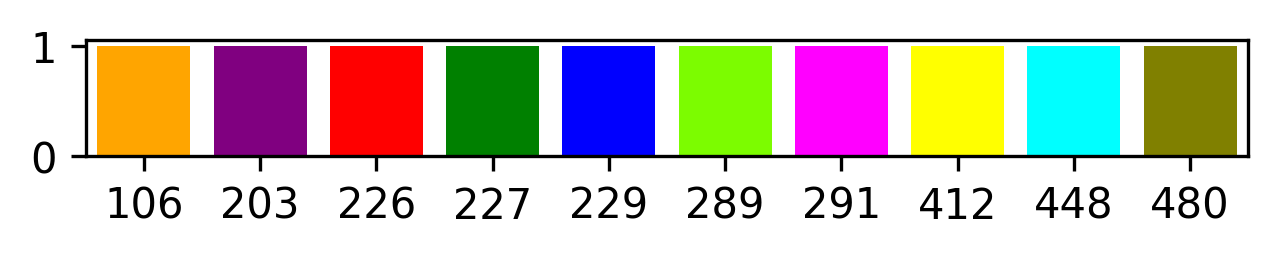

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [27]:
import py3Dmol

def show_protein(sites, chain_regions=None):
    # 创建一个视图对象
    view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js', width=600, height=600)
    view.addModels(open('1jsh.cif','r').read(),'cif', {'doAssembly':True,'duplicateAssemblyAtoms':True})
    
    # 设置默认样式
    for chain_type in ['A', 'B']:
        for chain in [f'{chain_type}', f'{chain_type}_2', f'{chain_type}_3']:
            view.setStyle({'chain':chain},{'cartoon':{'color':'gray', 'opacity':0.9}})
            
    for chain_type in ['C', 'D', 'E', 'F', 'G']:
        for chain in [f'{chain_type}', f'{chain_type}_2', f'{chain_type}_3']:
            view.setStyle({'chain':chain},{'cartoon':{'color':'white', 'opacity':0.1}})

    start, end = 1, 336
    chain = 'A'
    view.setStyle({'chain':chain, 'resi': f'{start}-{end}'}, {'cartoon':{'color': 'lightblue', 'opacity':1}})
    view.setStyle({'chain':f'{chain}_2', 'resi': f'{start}-{end}'}, {'cartoon':{'color':'lightblue', 'opacity':1}})
    view.setStyle({'chain':f'{chain}_3', 'resi': f'{start}-{end}'}, {'cartoon':{'color':'lightblue', 'opacity':1}})
    chain = 'B'
    start, end = 1, 161
    view.setStyle({'chain':chain, 'resi': f'{start}-{end}'}, {'cartoon':{'color':'lightyellow', 'opacity':1}})
    view.setStyle({'chain':f'{chain}_2', 'resi': f'{start}-{end}'}, {'cartoon':{'color':'lightyellow', 'opacity':1}})
    view.setStyle({'chain':f'{chain}_3', 'resi': f'{start}-{end}'}, {'cartoon':{'color':'lightyellow', 'opacity':1}})
    
    # 处理特定位点
    for site, color in sites.items():
        if site in list(range(19,336)):
            #print(f'site {site} in chain A as site {site-18}')
            site -= 18
            view.setStyle({'chain':'A', 'resi':site}, {'sphere':{'color':color, 'opacity':1}})
            view.setStyle({'chain':'A_2', 'resi':site}, {'sphere':{'color':color, 'opacity':1}})
            view.setStyle({'chain':'A_3', 'resi':site}, {'sphere':{'color':color, 'opacity':1}})
        elif site in list(range(339,499)):
            #print(f'site {site} in chain B as site {site-338}')
            site -= 338
            view.setStyle({'chain':'B', 'resi':site}, {'sphere':{'color':color, 'opacity':1}})
            view.setStyle({'chain':'B_2', 'resi':site}, {'sphere':{'color':color, 'opacity':1}})
            view.setStyle({'chain':'B_3', 'resi':site}, {'sphere':{'color':color, 'opacity':1}})
    


    
    # 生成颜色条
    plt.figure(figsize=(len(sites)/2, 0.5), dpi=300)
    i = 0
    for site, color in sites.items():
        plt.bar(i,1, color=color)
        i +=1
    plt.xticks(range(len(sites)), list([106, 203, 226, 227, 229, 289, 291, 412, 448, 480]))
    plt.xlim(-0.5,len(sites)-0.5)
    plt.savefig('color.pdf')
    plt.show()
    
    view.zoomTo()
    return view


# 定义链区域的颜色
chain_regions = {
    'A': [(19, 336, 'lightblue')],
    'B': [(339, 499, 'blue')]
}

sites = {117:'orange',
         211:'purple',
         234:'red', 
         235:'green', 
         237:'blue', 
         298:'lawngreen',
         300:'magenta', 
         421:'yellow', 
         448:'cyan',
         489:'olive', 
        }


# 调用函数
view = show_protein(sites, chain_regions)
view.show()